# Vox Deorum Analysis: Strategist Comparison

This notebook analyzes game results comparing different strategist conditions (excluding none-strategist).

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Import utility functions and CONDITION_MAPPING from the plot-utilities module
from plot_utilities import (
    load_panel_data,
    setup_notebook_display,
    plot_bar_chart,
    plot_grouped_bar_chart,
    plot_distribution_histograms,
    plot_strategy_radar_charts
)

# Set up notebook display and plotting style
setup_notebook_display(figsize=(10, 6))

# Load panel data using the unified function
panel_df = load_panel_data('../panel_data.csv', condition_exclude=["observe-vanilla-standard"])
panel_df.head()

✓ Loaded panel data: 1912 rows
✓ Filters applied: condition_exclude=['observe-vanilla-standard']
✓ Unique conditions: 13
✓ Unique player types: 15

Player Type Distribution:
  Vanilla: 646 rows (33.8%)
  GLM-4.7-Simple: 180 rows (9.4%)
  GLM-4.7-Briefed: 180 rows (9.4%)
  Kimi-K2.5-Simple: 127 rows (6.6%)
  Kimi-K2.5-Briefed: 127 rows (6.6%)
  GPT-OSS-120B-Briefed: 125 rows (6.5%)
  GPT-OSS-120B-Simple: 125 rows (6.5%)
  Deepseek-3.2-Briefed: 116 rows (6.1%)
  Deepseek-3.2-Simple: 116 rows (6.1%)
  Minimax-M2.5-Simple: 49 rows (2.6%)
  Minimax-M2.5-Briefed: 49 rows (2.6%)
  Sonnet-4.5-Simple: 28 rows (1.5%)
  Sonnet-4.5-Briefed: 28 rows (1.5%)
  Qwen-3.5-Briefed: 8 rows (0.4%)
  Qwen-3.5-Simple: 8 rows (0.4%)

Condition Distribution:
  2026-deepseek-v-kimi2-v-glm-standard: 664 rows (34.7%)
  2026-oss-v-glm-standard: 528 rows (27.6%)
  2026-deepseek-v-kimi2-v-minimax-standard: 160 rows (8.4%)
  2026-oss-v-sonnet-standard: 112 rows (5.9%)
  2026-deepseek-v-kimi-v-glm-standard: 88 rows (4

,experiment,game_id,turn,map_type,map_size,difficulty,game_speed,victory_type,victory_player_id,player_id,civilization,score,score_rank,score_ratio,survival_turn,is_winner,input_tokens,reasoning_tokens,output_tokens,strategy_changes,persona_changes,research_changes,policy_changes,nuke,use_nuke,domination_ratio,culture_ratio,diplomatic_ratio,science_ratio,tradition,authority,progress,fealty,statecraft,artistry,industry,imperialism,rationalism,freedom,autocracy,order,condition,player_type
0,2026-deepseek-v-kimi-v-glm-standard,085cfce3-75ee-4459-b7b0-c49c9a27f651,415,Vox_Deorum,Standard,Prince,Standard,Science,3,0,Polynesia,1543,7,0.3550,415,0,0.0,0.0,0.0,191,1,0,0,NaN,NaN,0.3614,0.1205,0.2530,0.2651,NaN,NaN,18.0,NaN,147.0,NaN,NaN,243.0,NaN,NaN,NaN,326.0,2026-deepseek-v-kimi-v-glm-standard,Vanilla
1,2026-deepseek-v-kimi-v-glm-standard,085cfce3-75ee-4459-b7b0-c49c9a27f651,415,Vox_Deorum,Standard,Prince,Standard,Science,3,1,Austria,2643,3,0.6080,415,0,0.0,0.0,0.0,220,1,0,0,50.0,50.0,0.0000,0.0240,0.5288,0.4471,NaN,NaN,17.0,132.0,NaN,NaN,224.0,NaN,NaN,318.0,NaN,NaN,2026-deepseek-v-kimi-v-glm-standard,Vanilla
2,2026-deepseek-v-kimi-v-glm-standard,085cfce3-75ee-4459-b7b0-c49c9a27f651,415,Vox_Deorum,Standard,Prince,Standard,Science,3,2,Babylon,1402,8,0.3225,415,0,13700445.0,1213318.0,230753.0,251,65,65,47,NaN,NaN,0.0000,0.1226,0.0120,0.8654,18.0,NaN,28.0,211.0,NaN,257.0,300.0,346.0,279.0,NaN,NaN,363.0,2026-deepseek-v-kimi-v-glm-standard,Kimi-K2.5-Simple
3,2026-deepseek-v-kimi-v-glm-standard,085cfce3-75ee-4459-b7b0-c49c9a27f651,415,Vox_Deorum,Standard,Prince,Standard,Science,3,3,Portugal,4196,2,0.9653,415,1,29105306.0,1695836.0,2678364.0,304,75,91,76,40.0,40.0,0.0000,0.0120,0.9760,0.0120,113.0,NaN,16.0,NaN,126.0,NaN,237.0,NaN,225.0,NaN,NaN,290.0,2026-deepseek-v-kimi-v-glm-standard,Kimi-K2.5-Briefed
4,2026-deepseek-v-kimi-v-glm-standard,085cfce3-75ee-4459-b7b0-c49c9a27f651,415,Vox_Deorum,Standard,Prince,Standard,Science,3,4,Mongolia,2466,4,0.5673,415,0,14763017.0,811214.0,260286.0,214,99,94,57,100.0,100.0,1.0000,0.0000,0.0000,0.0000,200.0,16.0,126.0,220.0,259.0,178.0,366.0,296.0,346.0,NaN,366.0,NaN,2026-deepseek-v-kimi-v-glm-standard,GLM-4.7-Simple


## 1. Win Rate of Each Player by Condition

Comparing win rates for each player (0-3) between none-strategist and simple-strategist conditions.

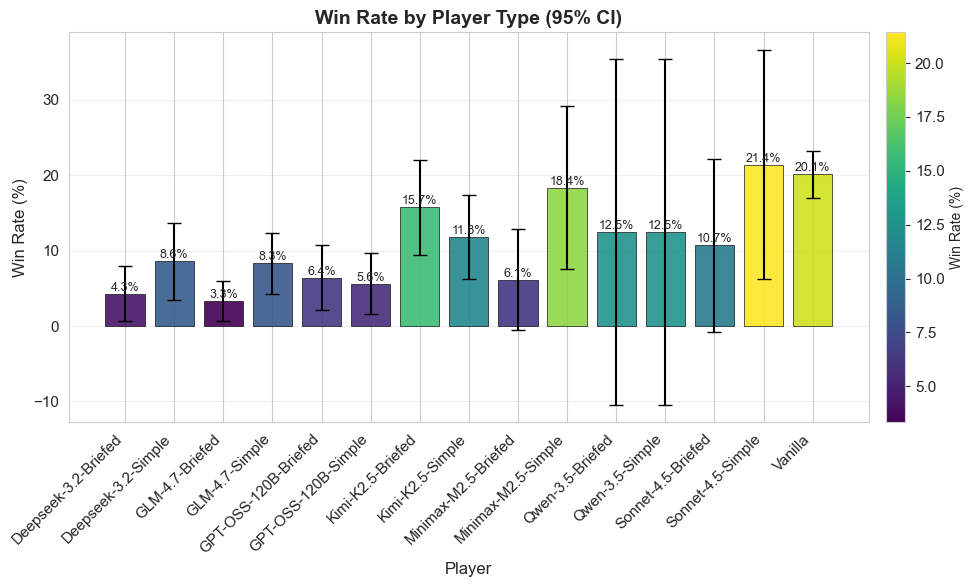

,is_winner=1
Deepseek-3.2-Briefed,5/116 (4.3%)
Deepseek-3.2-Simple,10/116 (8.6%)
GLM-4.7-Briefed,6/180 (3.3%)
GLM-4.7-Simple,15/180 (8.3%)
GPT-OSS-120B-Briefed,8/125 (6.4%)
GPT-OSS-120B-Simple,7/125 (5.6%)
Kimi-K2.5-Briefed,20/127 (15.7%)
Kimi-K2.5-Simple,15/127 (11.8%)
Minimax-M2.5-Briefed,3/49 (6.1%)
Minimax-M2.5-Simple,9/49 (18.4%)


In [2]:
# Create the chart and print summary  
plot_bar_chart(
    panel_df,
    value_col='is_winner',
    category_col='player_type',
    xlabel='Player',
    ylabel='Win Rate (%)',
    title='Win Rate by Player Type',
    use_percentage=True,
    show_error_bars=True
)

## 2. Victory Type Distribution by Condition

Analyzing the types of victories (Cultural, Diplomatic, Domination, Science, Time) across conditions.

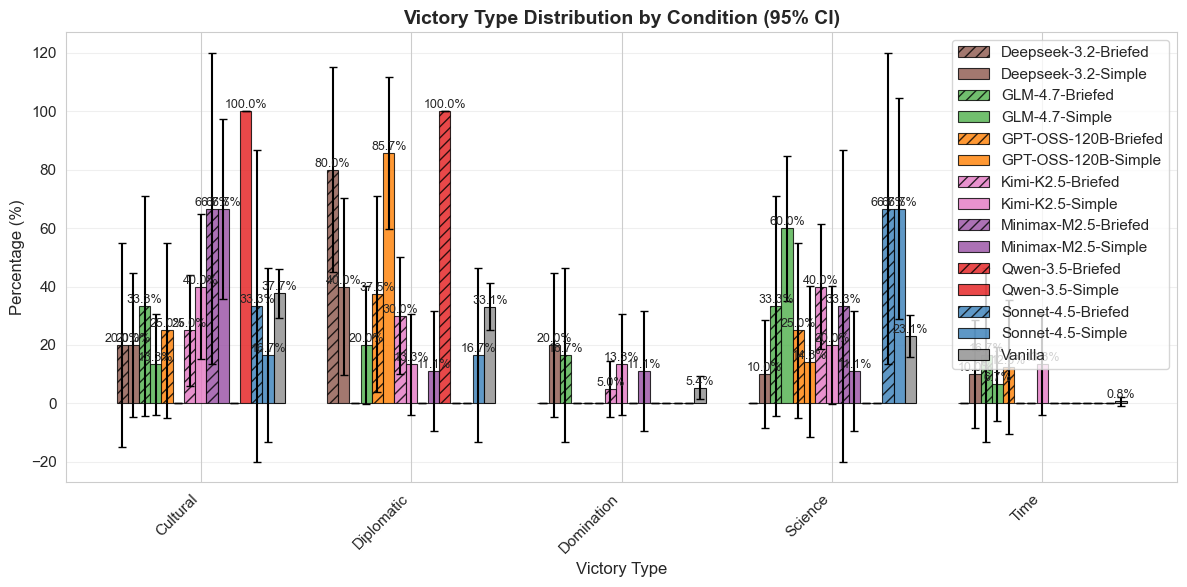

victory_type,Cultural,Diplomatic,Domination,Science,Time
Deepseek-3.2-Briefed,1 (20.0%),4 (80.0%),0 (0.0%),0 (0.0%),0 (0.0%)
Deepseek-3.2-Simple,2 (20.0%),4 (40.0%),2 (20.0%),1 (10.0%),1 (10.0%)
GLM-4.7-Briefed,2 (33.3%),0 (0.0%),1 (16.7%),2 (33.3%),1 (16.7%)
GLM-4.7-Simple,2 (13.3%),3 (20.0%),0 (0.0%),9 (60.0%),1 (6.7%)
GPT-OSS-120B-Briefed,2 (25.0%),3 (37.5%),0 (0.0%),2 (25.0%),1 (12.5%)
GPT-OSS-120B-Simple,0 (0.0%),6 (85.7%),0 (0.0%),1 (14.3%),0 (0.0%)
Kimi-K2.5-Briefed,5 (25.0%),6 (30.0%),1 (5.0%),8 (40.0%),0 (0.0%)
Kimi-K2.5-Simple,6 (40.0%),2 (13.3%),2 (13.3%),3 (20.0%),2 (13.3%)
Minimax-M2.5-Briefed,2 (66.7%),0 (0.0%),0 (0.0%),1 (33.3%),0 (0.0%)
Minimax-M2.5-Simple,6 (66.7%),1 (11.1%),1 (11.1%),1 (11.1%),0 (0.0%)


In [3]:
# Victory type distribution
plot_grouped_bar_chart(
    panel_df[panel_df["is_winner"] == 1],
    value_col=None,  # Not used when use_percentage=True
    category_col='victory_type',
    xlabel='Victory Type',
    ylabel='Percentage (%)',
    title='Victory Type Distribution by Condition',
    use_percentage=True,
    show_error_bars=True,
    rotation=45
)

## 3. Choice of Ideology

C:\Users\John Chen\AppData\Local\Temp\ipykernel_337244\1159868436.py:5: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  .idxmin(axis=1)


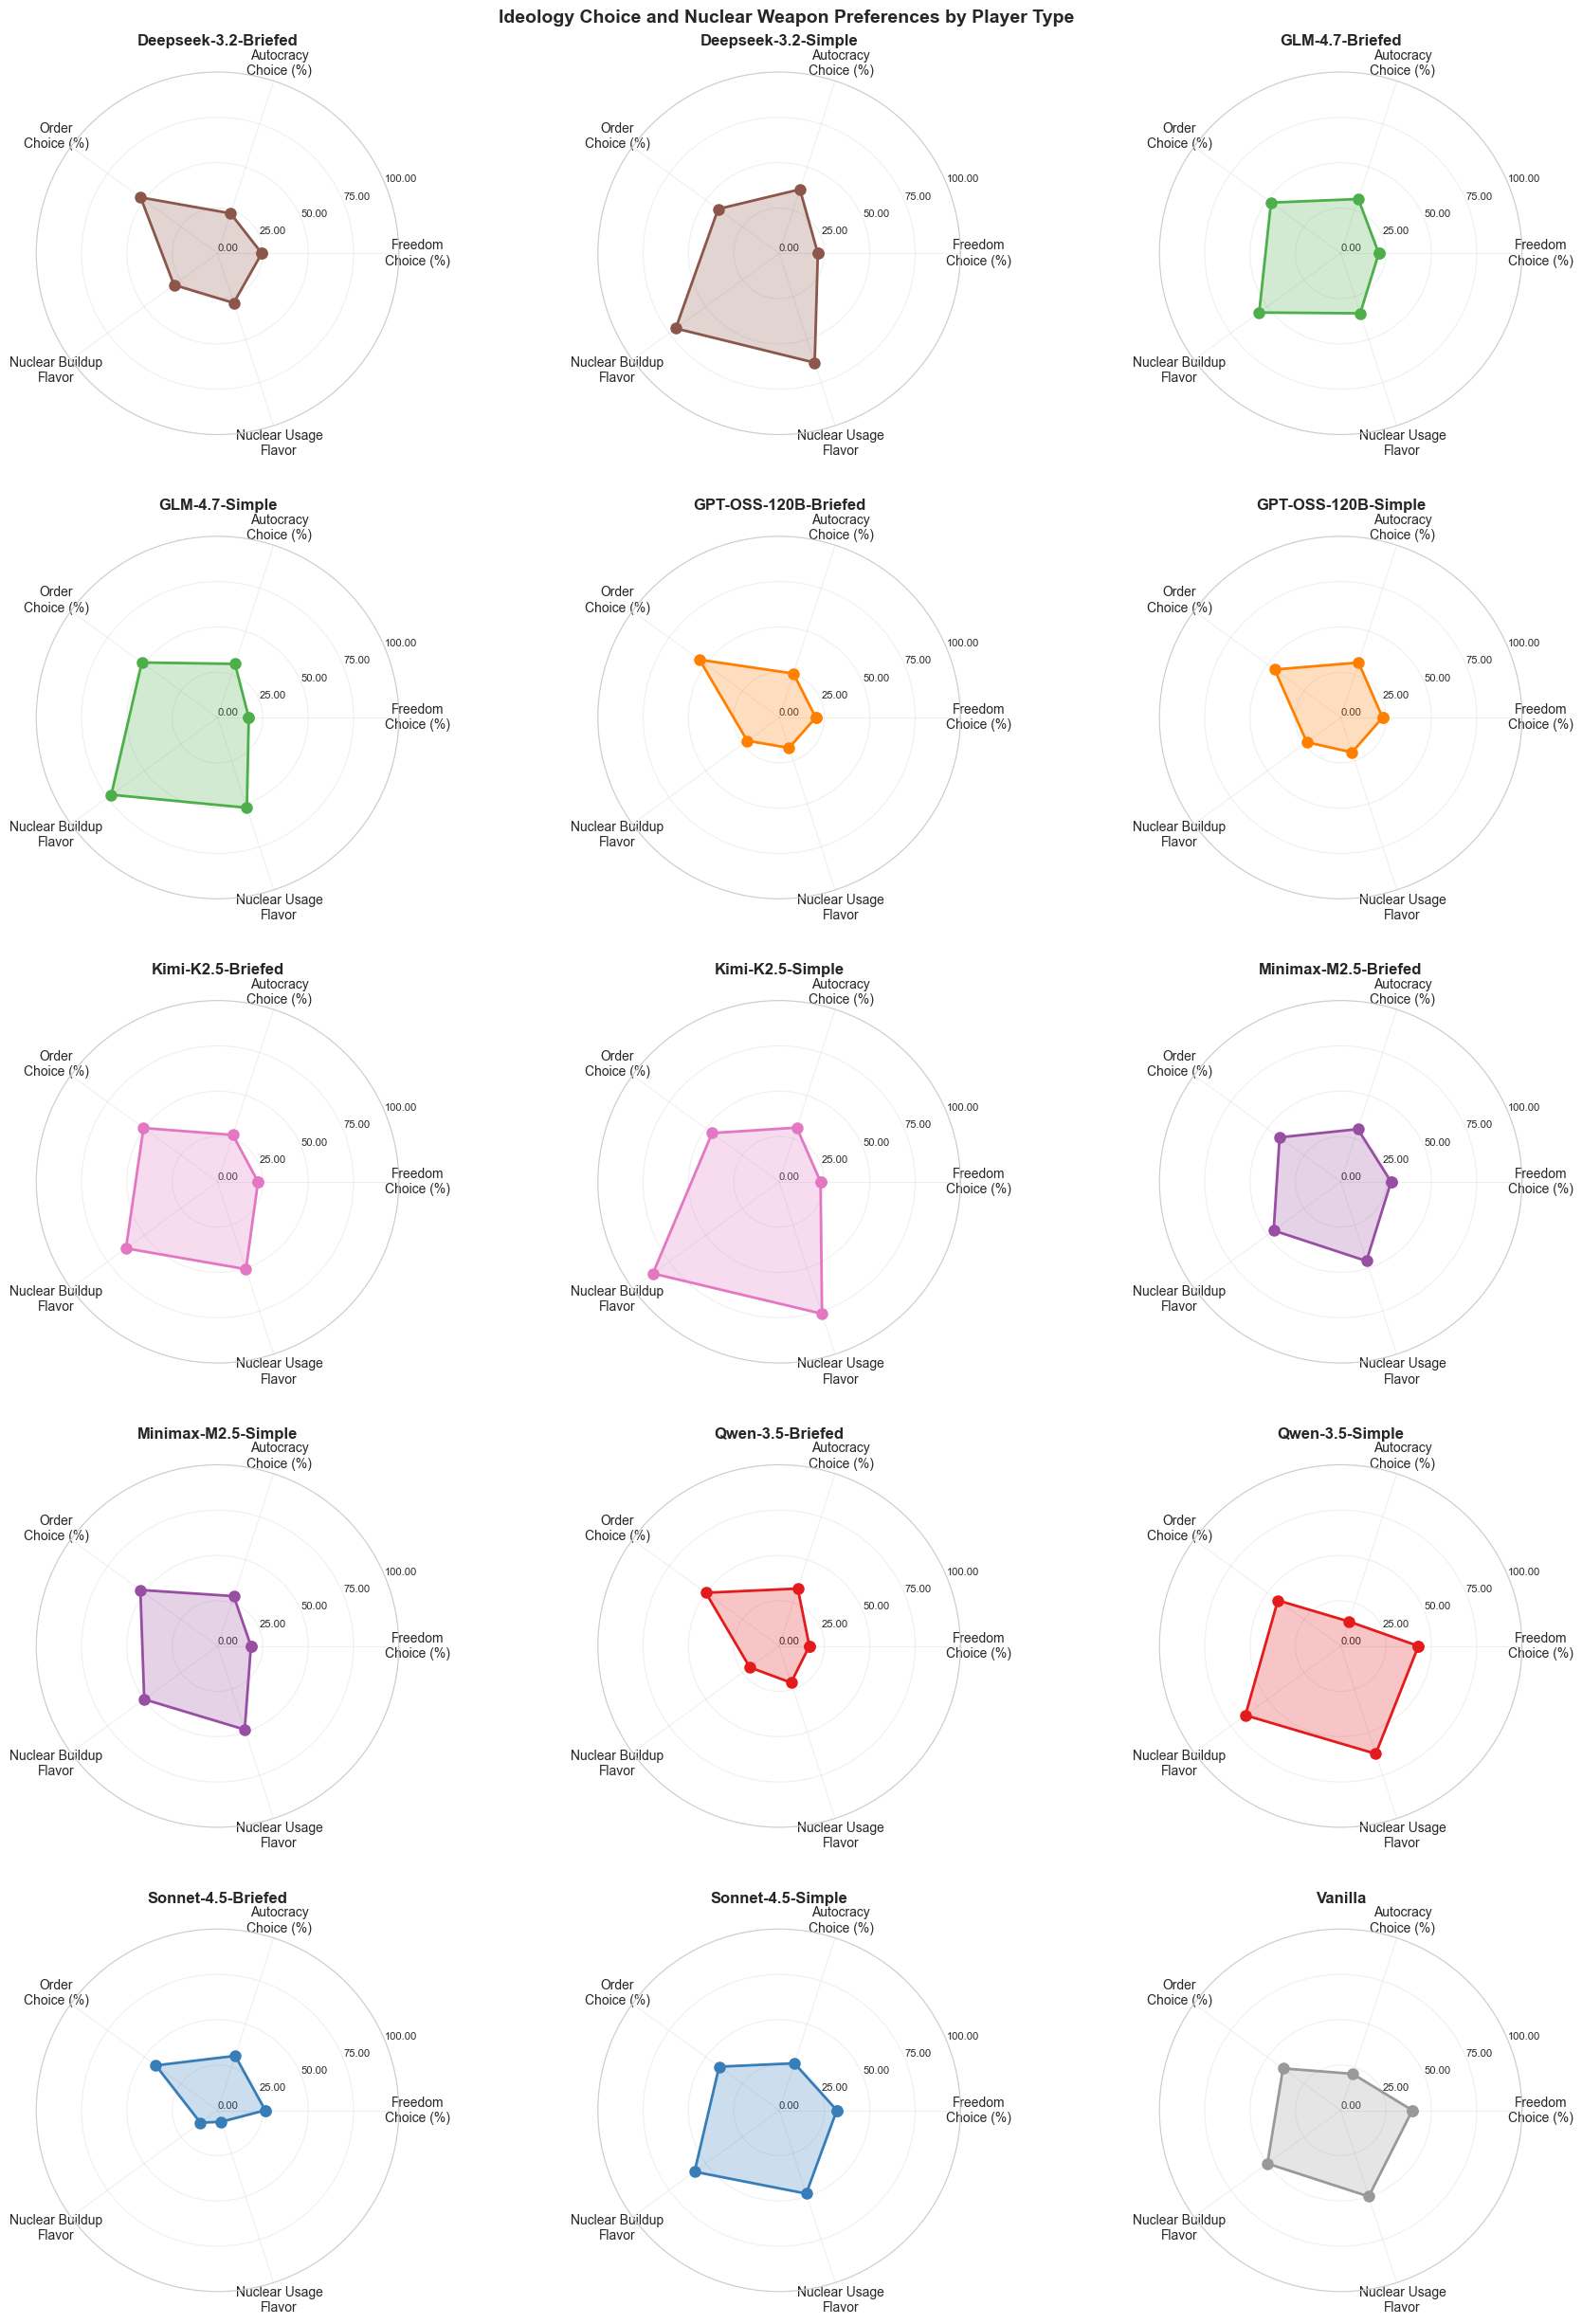


Ideology Choice and Nuclear Weapon Preferences by Player Type Summary:


c:\Users\John Chen\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\John Chen\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


,N,Freedom Choice (%),Autocracy Choice (%),Order Choice (%),Nuclear Buildup Flavor,Nuclear Usage Flavor
Deepseek-3.2-Briefed,116,"24.390 [14.896, 33.884]","23.171 [13.843, 32.498]","52.439 [41.398, 63.480]","29.697 [19.997, 39.397]","28.788 [19.302, 38.274]"
Deepseek-3.2-Simple,116,"21.348 [12.668, 30.029]","37.079 [26.846, 47.311]","41.573 [31.132, 52.014]","70.513 [58.092, 82.934]","63.462 [50.510, 76.413]"
GLM-4.7-Briefed,180,"20.979 [14.225, 27.733]","31.469 [23.765, 39.172]","47.552 [39.268, 55.837]","55.609 [48.393, 62.824]","34.826 [28.684, 40.968]"
GLM-4.7-Simple,180,"17.219 [11.128, 23.309]","31.126 [23.656, 38.596]","51.656 [43.593, 59.718]","72.473 [66.340, 78.606]","52.333 [46.536, 58.130]"
GPT-OSS-120B-Briefed,125,"20.213 [11.943, 28.482]","25.532 [16.553, 34.511]","54.255 [43.997, 64.514]","21.771 [16.746, 26.796]","17.604 [13.597, 21.611]"
GPT-OSS-120B-Simple,125,"23.077 [14.254, 31.900]","31.868 [22.110, 41.626]","45.055 [34.636, 55.474]","23.137 [15.798, 30.477]","20.196 [13.703, 26.689]"
Kimi-K2.5-Briefed,127,"22.330 [14.151, 30.509]","27.184 [18.447, 35.922]","50.485 [40.666, 60.305]","62.462 [54.671, 70.252]","50.692 [43.729, 57.656]"
Kimi-K2.5-Simple,127,"22.857 [14.692, 31.022]","31.429 [22.401, 40.456]","45.714 [36.027, 55.401]","86.083 [80.214, 91.952]","76.550 [68.747, 84.353]"
Minimax-M2.5-Briefed,49,"27.778 [12.408, 43.148]","30.556 [14.749, 46.363]","41.667 [24.749, 58.584]","45.714 [40.611, 50.818]","45.952 [39.450, 52.455]"
Minimax-M2.5-Simple,49,"18.421 [5.508, 31.334]","28.947 [13.840, 44.054]","52.632 [35.999, 69.264]","50.000 [nan, nan]","48.462 [45.110, 51.814]"


(<Figure size 1800x2500 with 15 Axes>,
 array([<PolarAxes: title={'center': 'Deepseek-3.2-Briefed'}>,
        <PolarAxes: title={'center': 'Deepseek-3.2-Simple'}>,
        <PolarAxes: title={'center': 'GLM-4.7-Briefed'}>,
        <PolarAxes: title={'center': 'GLM-4.7-Simple'}>,
        <PolarAxes: title={'center': 'GPT-OSS-120B-Briefed'}>,
        <PolarAxes: title={'center': 'GPT-OSS-120B-Simple'}>,
        <PolarAxes: title={'center': 'Kimi-K2.5-Briefed'}>,
        <PolarAxes: title={'center': 'Kimi-K2.5-Simple'}>,
        <PolarAxes: title={'center': 'Minimax-M2.5-Briefed'}>,
        <PolarAxes: title={'center': 'Minimax-M2.5-Simple'}>,
        <PolarAxes: title={'center': 'Qwen-3.5-Briefed'}>,
        <PolarAxes: title={'center': 'Qwen-3.5-Simple'}>,
        <PolarAxes: title={'center': 'Sonnet-4.5-Briefed'}>,
        <PolarAxes: title={'center': 'Sonnet-4.5-Simple'}>,
        <PolarAxes: title={'center': 'Vanilla'}>], dtype=object))

In [4]:
# Choice of ideology (first adopted among freedom/autocracy/order)
ideology_cols = ['freedom', 'autocracy', 'order']
panel_df['ideology_choice'] = (
    panel_df[ideology_cols]
    .idxmin(axis=1)
    .where(panel_df[ideology_cols].notna().any(axis=1), None)
    .str.title()
)

# Create binary columns for each ideology choice (0-100 scale to match nuclear flavors)
# Only set values for games where an ideology was actually adopted
panel_df['freedom_pct'] = None
panel_df['autocracy_pct'] = None
panel_df['order_pct'] = None

# Only calculate for games with ideology choice
ideology_mask = panel_df['ideology_choice'].notna()
panel_df.loc[ideology_mask, 'freedom_pct'] = (panel_df.loc[ideology_mask, 'ideology_choice'] == 'Freedom').astype(float) * 100
panel_df.loc[ideology_mask, 'autocracy_pct'] = (panel_df.loc[ideology_mask, 'ideology_choice'] == 'Autocracy').astype(float) * 100
panel_df.loc[ideology_mask, 'order_pct'] = (panel_df.loc[ideology_mask, 'ideology_choice'] == 'Order').astype(float) * 100

# Create radar chart showing ideology choices and nuclear flavors by player type
plot_strategy_radar_charts(
    panel_df,
    columns=['freedom_pct', 'autocracy_pct', 'order_pct', 'nuke', 'use_nuke'],
    labels=['Freedom\nChoice (%)', 'Autocracy\nChoice (%)', 'Order\nChoice (%)', 
            'Nuclear Buildup\nFlavor', 'Nuclear Usage\nFlavor'],
    title='Ideology Choice and Nuclear Weapon Preferences by Player Type',
    ylim=(0, 100),
    print_summary=True
)

## 4. Survival Rate (Survival Turns / Game Length)

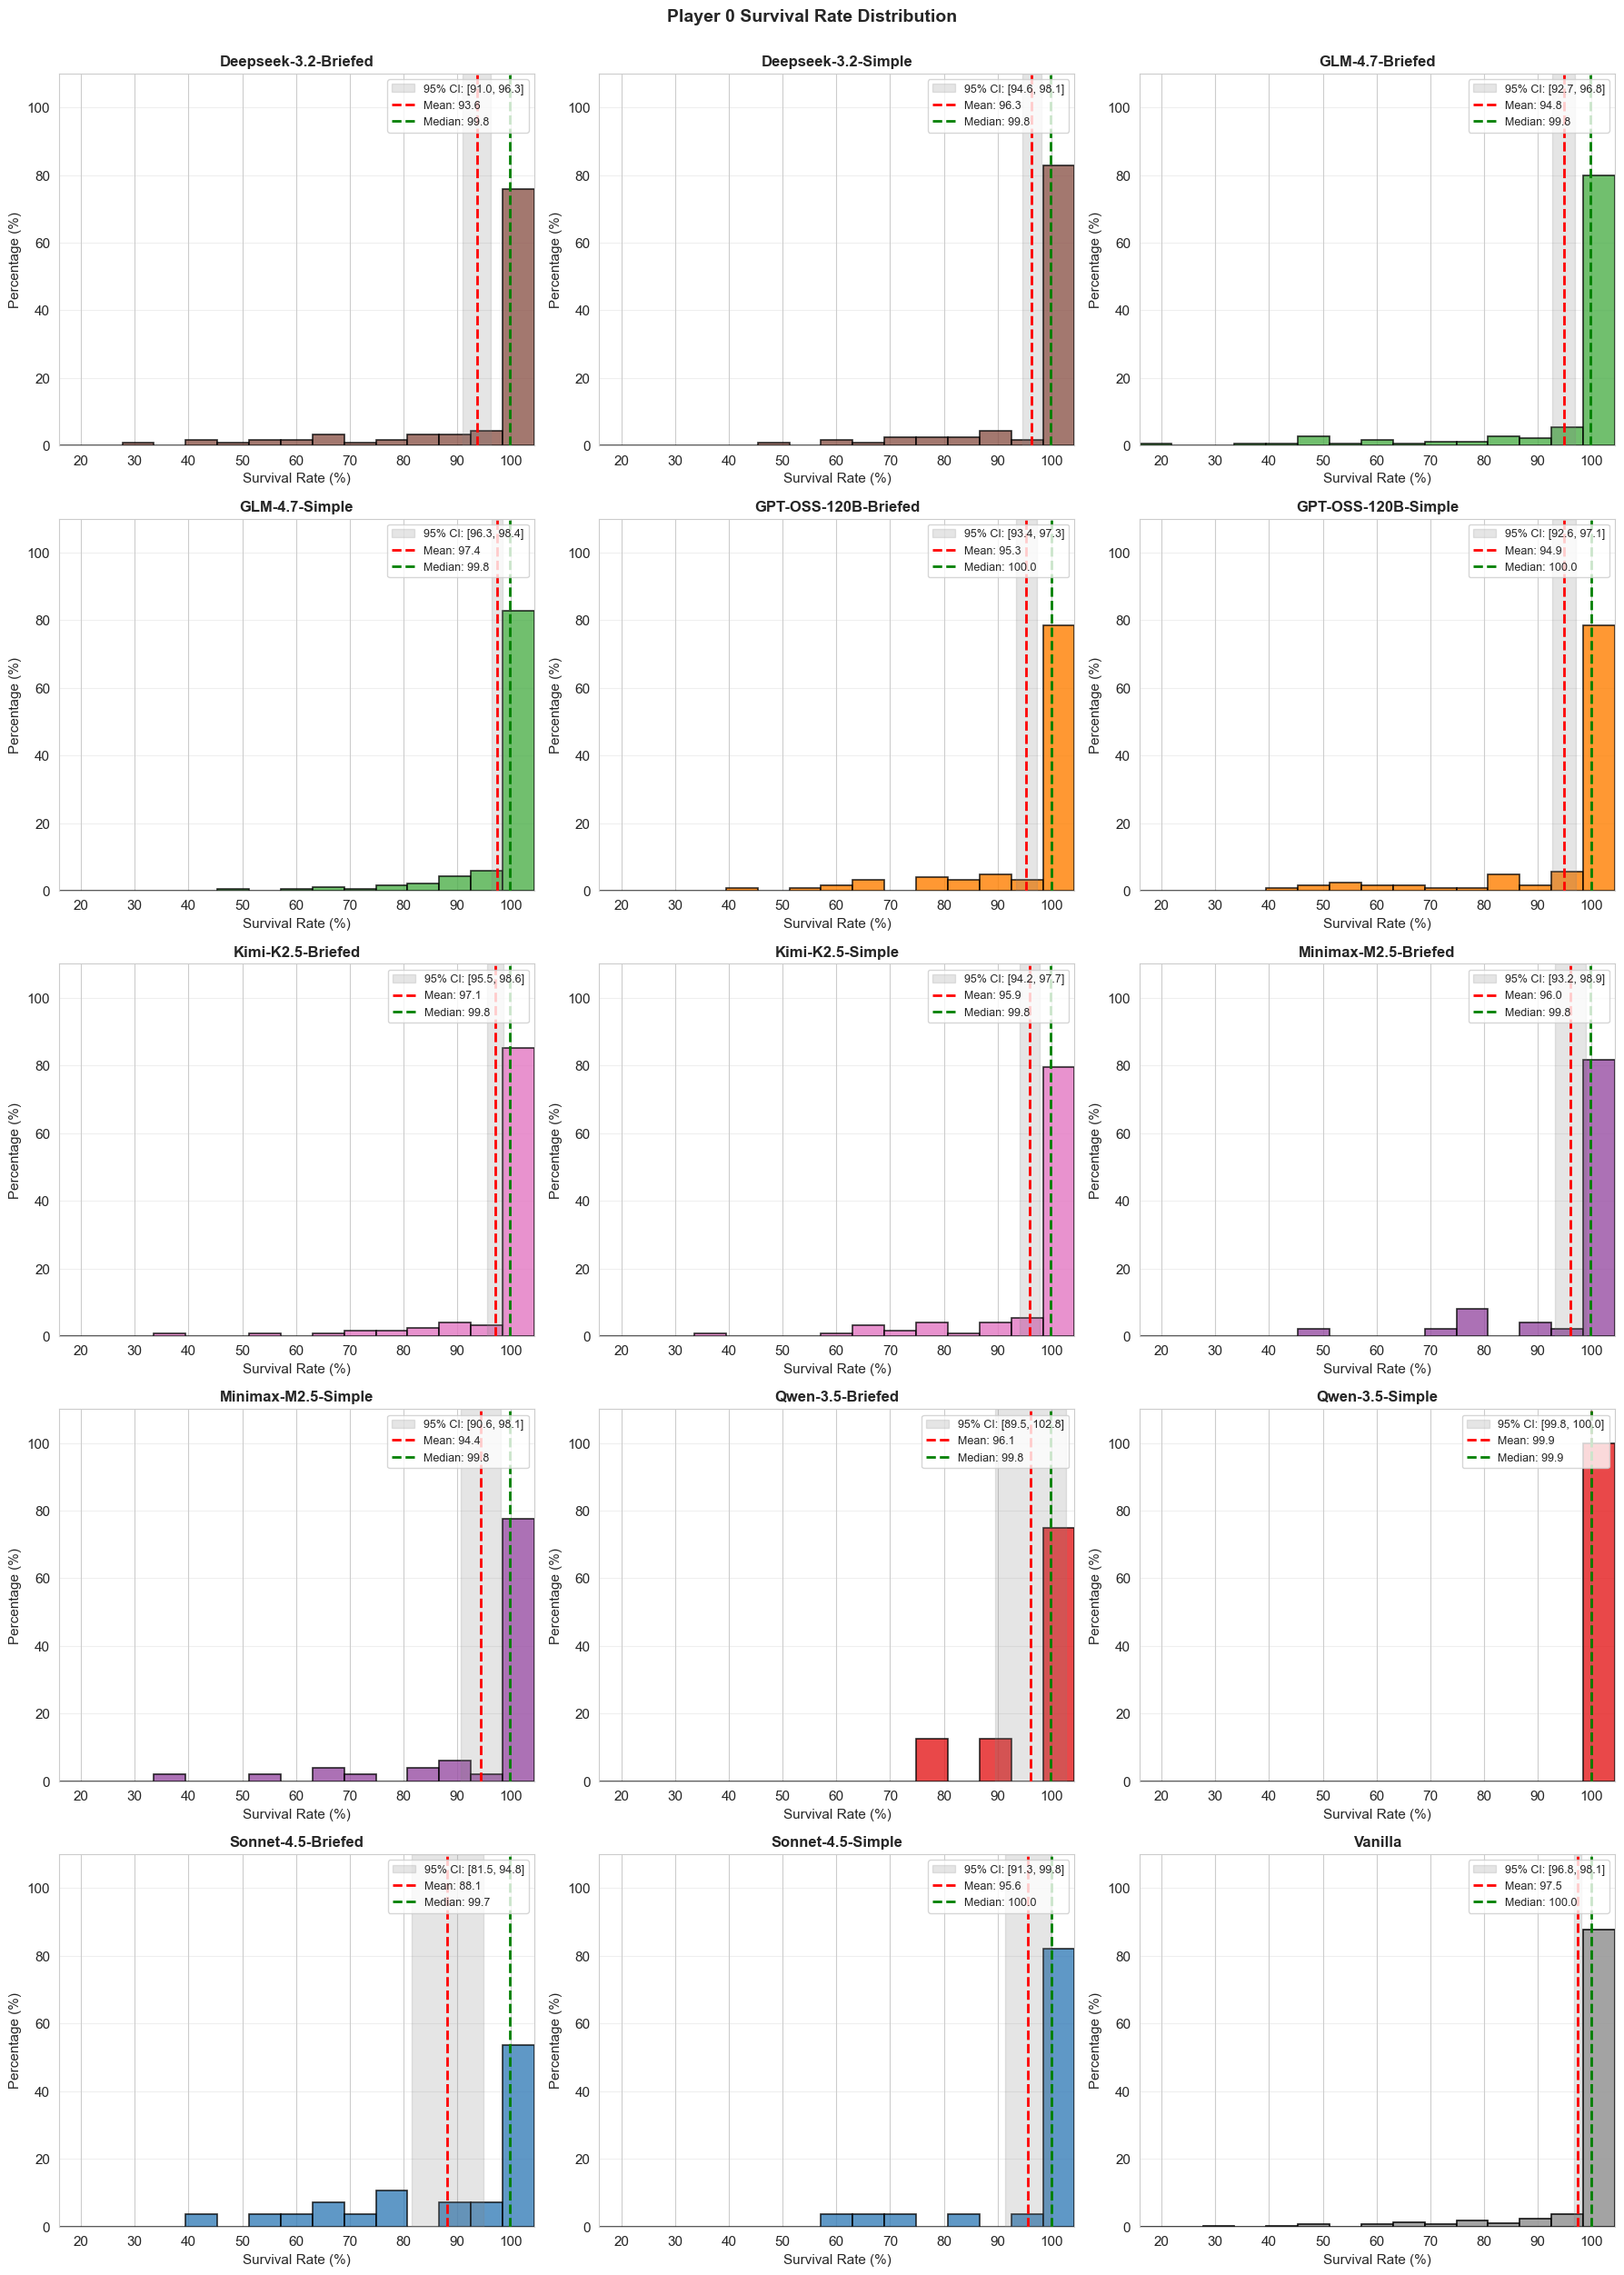


Player 0 Survival Rate Distribution Statistics:


,N,Mean,Median,Std,Min,Max,95% CI
Deepseek-3.2-Briefed,116,93.61,99.77,14.45,33.2,100.0,"[90.96, 96.27]"
Deepseek-3.2-Simple,116,96.34,99.79,9.41,48.5,100.0,"[94.61, 98.07]"
GLM-4.7-Briefed,180,94.78,99.78,14.00,19.9,100.0,"[92.72, 96.84]"
GLM-4.7-Simple,180,97.37,99.78,7.27,48.4,100.3,"[96.30, 98.43]"
GPT-OSS-120B-Briefed,125,95.31,100.00,10.96,42.2,100.3,"[93.37, 97.25]"
GPT-OSS-120B-Simple,125,94.87,100.00,12.67,43.7,100.3,"[92.62, 97.11]"
Kimi-K2.5-Briefed,127,97.09,99.80,8.80,39.0,100.0,"[95.55, 98.64]"
Kimi-K2.5-Simple,127,95.95,99.78,10.16,38.6,100.0,"[94.16, 97.73]"
Minimax-M2.5-Briefed,49,96.04,99.79,10.04,47.2,100.0,"[93.15, 98.92]"
Minimax-M2.5-Simple,49,94.38,99.78,12.98,38.9,100.0,"[90.65, 98.10]"


In [5]:
# Calculate survival rate (survival turns / game length)
panel_df['survival_rate'] = panel_df['survival_turn'] / panel_df['turn'] * 100

# Use the reusable function for distribution histograms
plot_distribution_histograms(
    panel_df,
    'survival_rate',
    'Survival Rate (%)',
    'Player 0 Survival Rate Distribution'
)

## 5. Highest Ranking by Condition

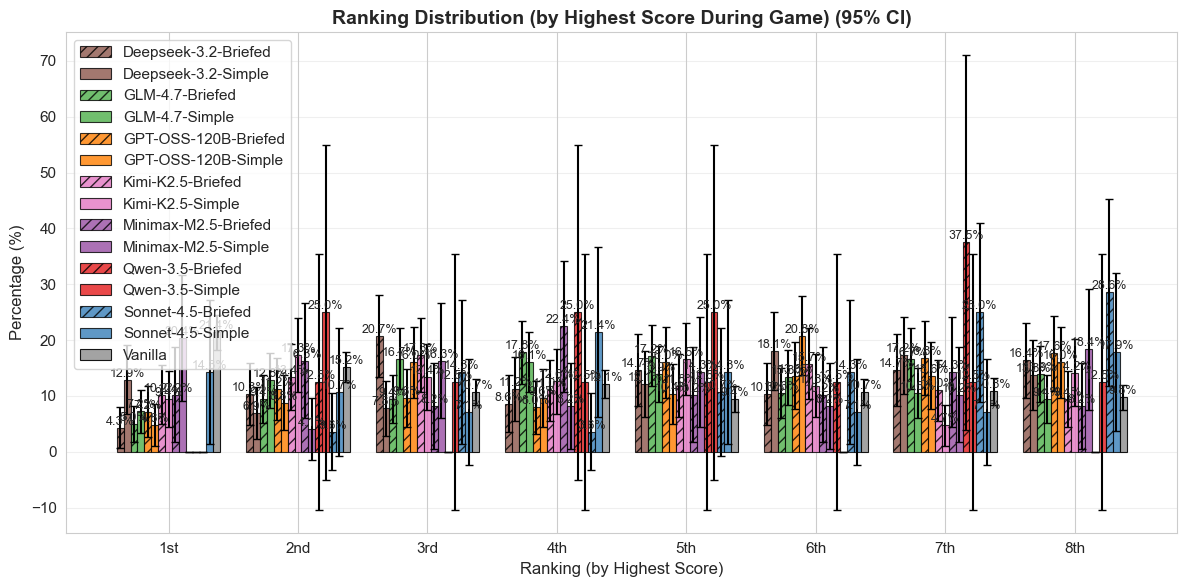

,1st,2nd,3rd,4th,5th,6th,7th,8th
Deepseek-3.2-Briefed,5 (4.3%),12 (10.3%),24 (20.7%),10 (8.6%),17 (14.7%),12 (10.3%),17 (14.7%),19 (16.4%)
Deepseek-3.2-Simple,15 (12.9%),8 (6.9%),9 (7.8%),13 (11.2%),14 (12.1%),21 (18.1%),20 (17.2%),16 (13.8%)
GLM-4.7-Briefed,9 (5.0%),17 (9.4%),17 (9.4%),32 (17.8%),31 (17.2%),19 (10.6%),30 (16.7%),25 (13.9%)
GLM-4.7-Simple,13 (7.2%),23 (12.8%),30 (16.7%),29 (16.1%),25 (13.9%),24 (13.3%),19 (10.6%),17 (9.4%)
GPT-OSS-120B-Briefed,9 (7.2%),14 (11.2%),12 (9.6%),10 (8.0%),20 (16.0%),17 (13.6%),21 (16.8%),22 (17.6%)
GPT-OSS-120B-Simple,6 (4.8%),11 (8.8%),20 (16.0%),12 (9.6%),13 (10.4%),26 (20.8%),17 (13.6%),20 (16.0%)
Kimi-K2.5-Briefed,13 (10.2%),17 (13.4%),22 (17.3%),14 (11.0%),15 (11.8%),20 (15.7%),14 (11.0%),12 (9.4%)
Kimi-K2.5-Simple,12 (9.4%),22 (17.3%),17 (13.4%),16 (12.6%),21 (16.5%),15 (11.8%),6 (4.7%),18 (14.2%)
Minimax-M2.5-Briefed,5 (10.2%),8 (16.3%),4 (8.2%),11 (22.4%),5 (10.2%),5 (10.2%),7 (14.3%),4 (8.2%)
Minimax-M2.5-Simple,10 (20.4%),2 (4.1%),8 (16.3%),4 (8.2%),7 (14.3%),4 (8.2%),5 (10.2%),9 (18.4%)


In [6]:
# Player 0 ranking distribution (based on highest score during game)
plot_grouped_bar_chart(
    panel_df,
    value_col=None,  # Not used when use_percentage=True
    category_col='score_rank',
    xlabel='Ranking (by Highest Score)',
    ylabel='Percentage (%)',
    title='Ranking Distribution (by Highest Score During Game)',
    use_percentage=True,
    show_error_bars=True,
    x_labels=['1st', '2nd', '3rd', '4th', '5th', '6th', '7th', '8th']
)

## 6. Score Ratio Distribution

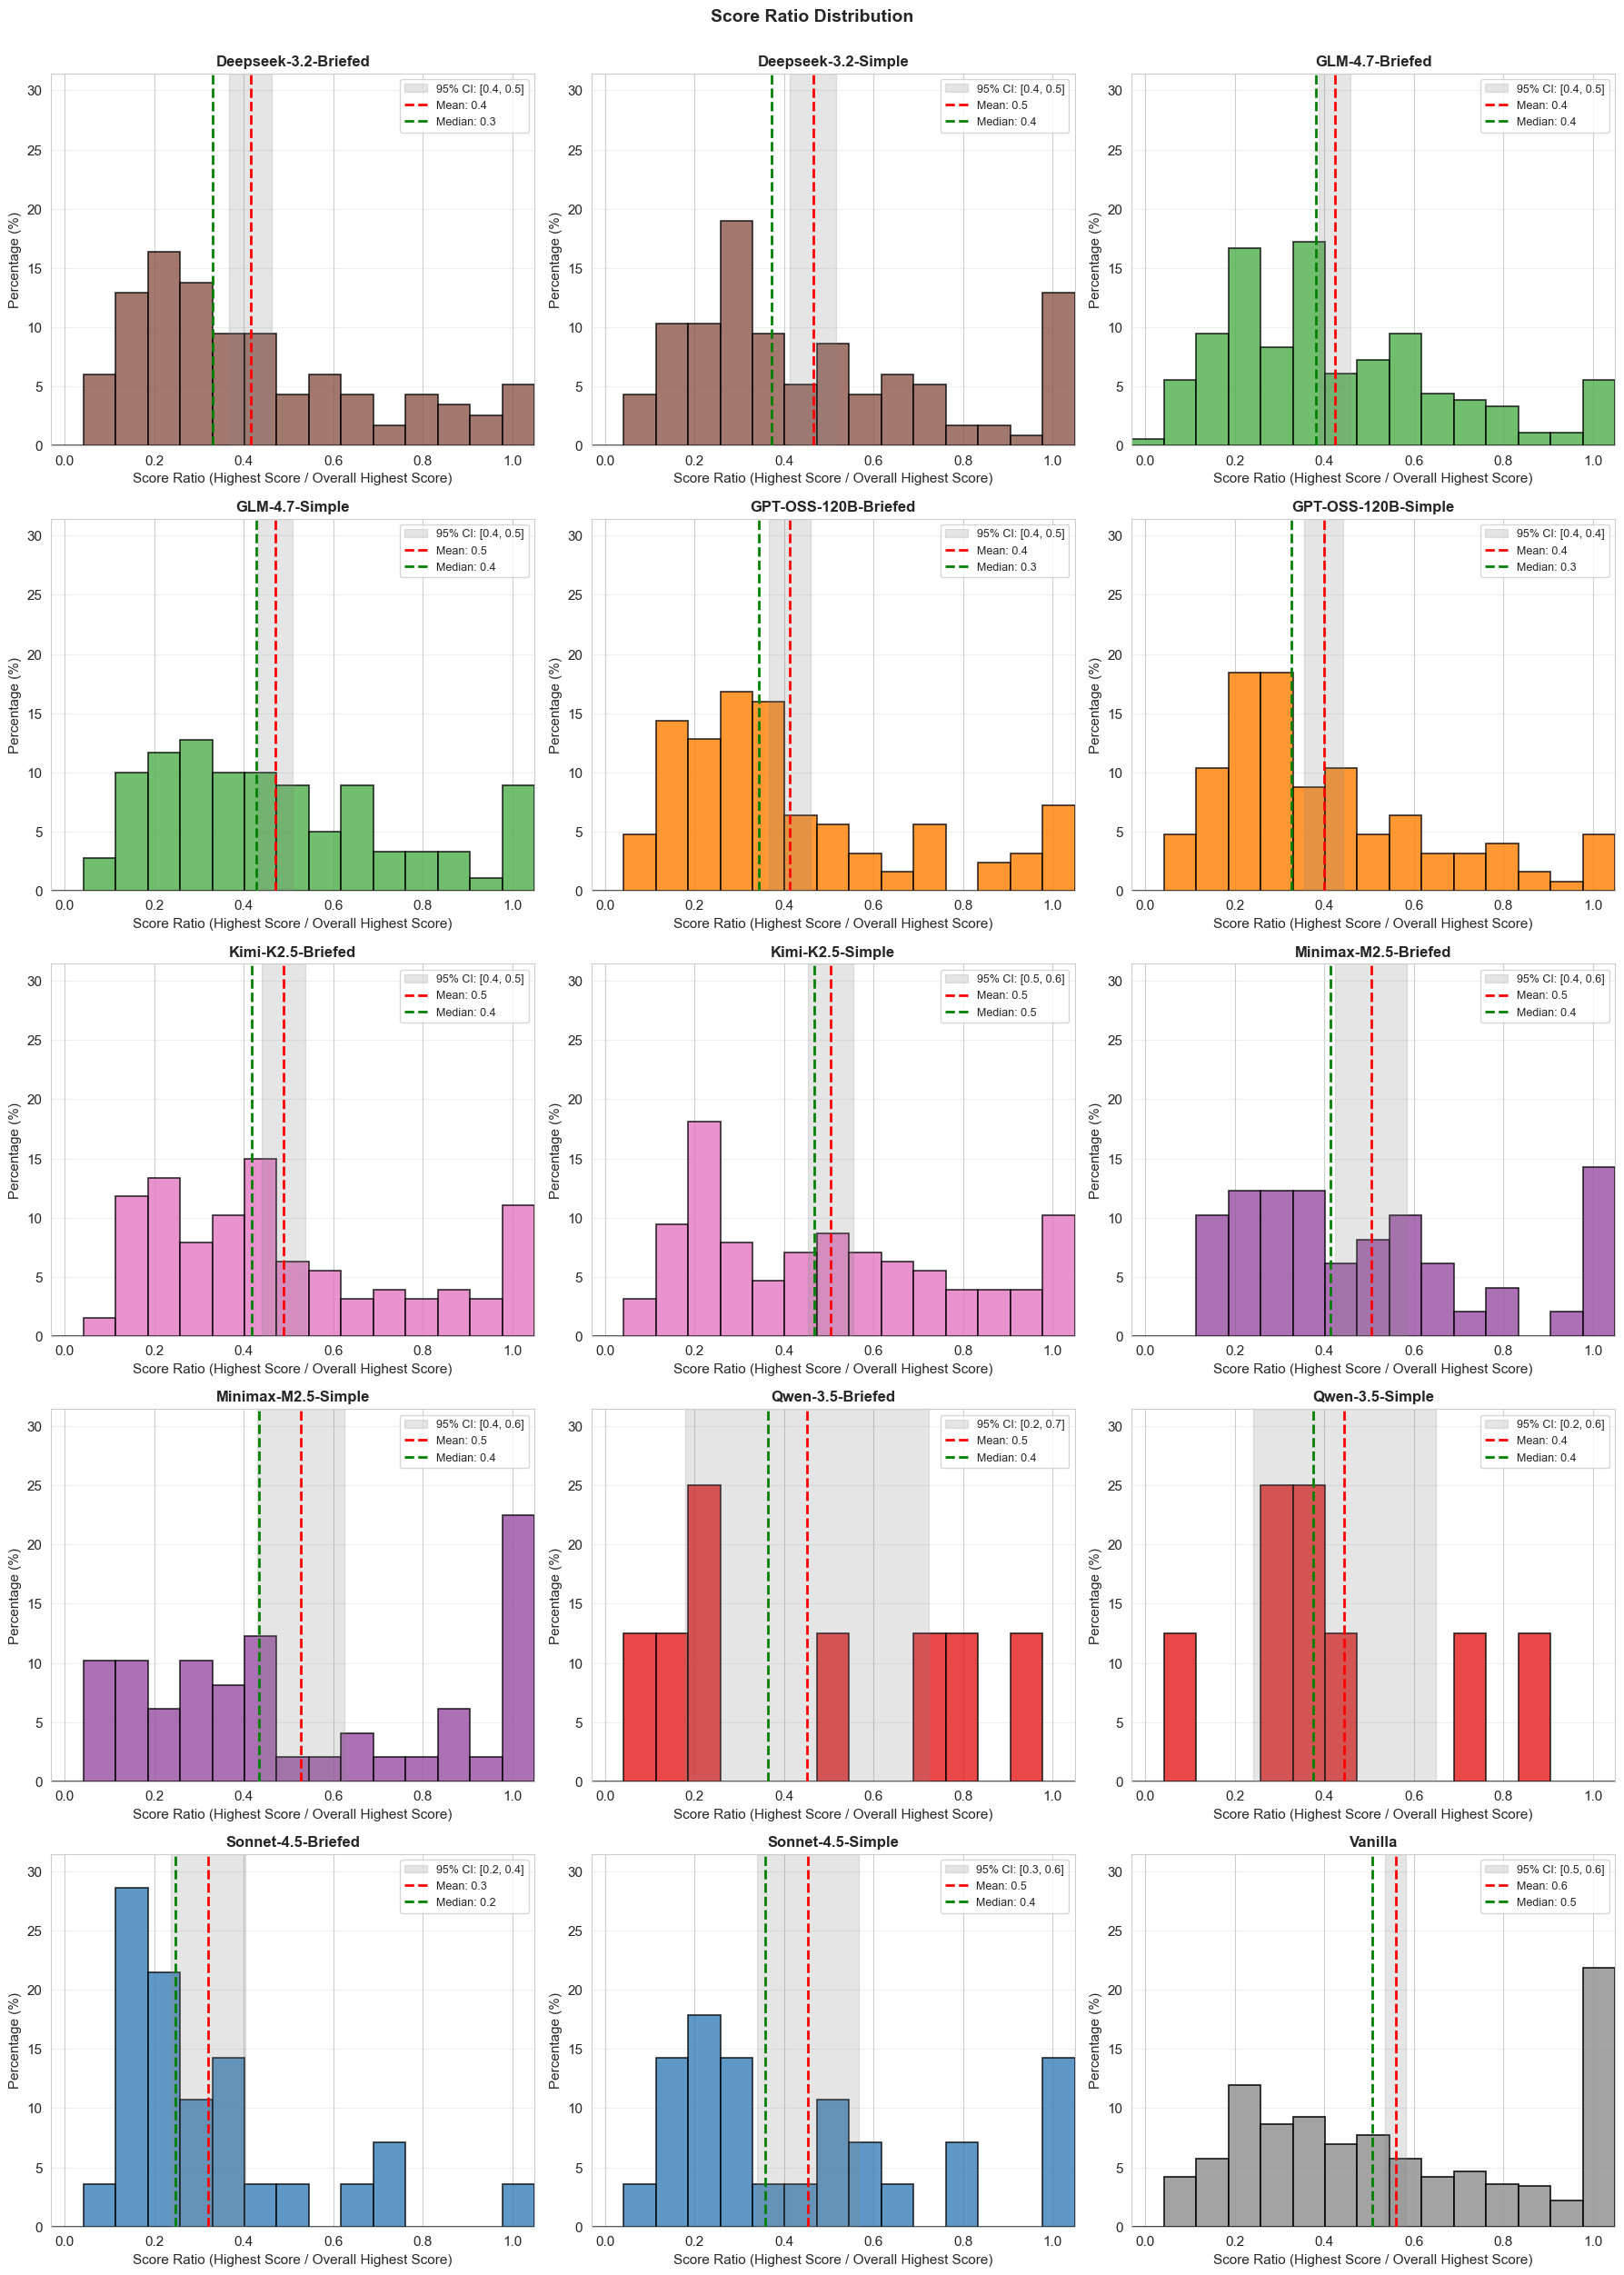


Score Ratio Distribution Statistics:


,N,Mean,Median,Std,Min,Max,95% CI
Deepseek-3.2-Briefed,116,0.41,0.33,0.26,0.0,1.0,"[0.37, 0.46]"
Deepseek-3.2-Simple,116,0.46,0.37,0.28,0.1,1.0,"[0.41, 0.52]"
GLM-4.7-Briefed,180,0.42,0.38,0.25,0.0,1.0,"[0.39, 0.46]"
GLM-4.7-Simple,180,0.47,0.43,0.26,0.1,1.0,"[0.43, 0.51]"
GPT-OSS-120B-Briefed,125,0.41,0.34,0.26,0.1,1.0,"[0.37, 0.46]"
GPT-OSS-120B-Simple,125,0.40,0.33,0.24,0.1,1.0,"[0.36, 0.44]"
Kimi-K2.5-Briefed,127,0.49,0.42,0.28,0.1,1.0,"[0.44, 0.54]"
Kimi-K2.5-Simple,127,0.50,0.47,0.29,0.1,1.0,"[0.45, 0.55]"
Minimax-M2.5-Briefed,49,0.50,0.41,0.28,0.1,1.0,"[0.42, 0.58]"
Minimax-M2.5-Simple,49,0.53,0.43,0.34,0.1,1.0,"[0.43, 0.62]"


In [7]:
# Player 0 Score Ratio Distribution
plot_distribution_histograms(
    panel_df, 
    'score_ratio',
    'Score Ratio (Highest Score / Overall Highest Score)',
    'Score Ratio Distribution'
)

## 7. Grand Strategy Choice Distributions

Analyzing how long Player 0 pursued each victory condition as their grand strategy during the game. These ratios (0-1 scale) represent the proportion of the game where Player 0 chose each victory type as their primary strategy.

We also include strategy and persona change rates (changes per turn of survival) to understand adaptability.

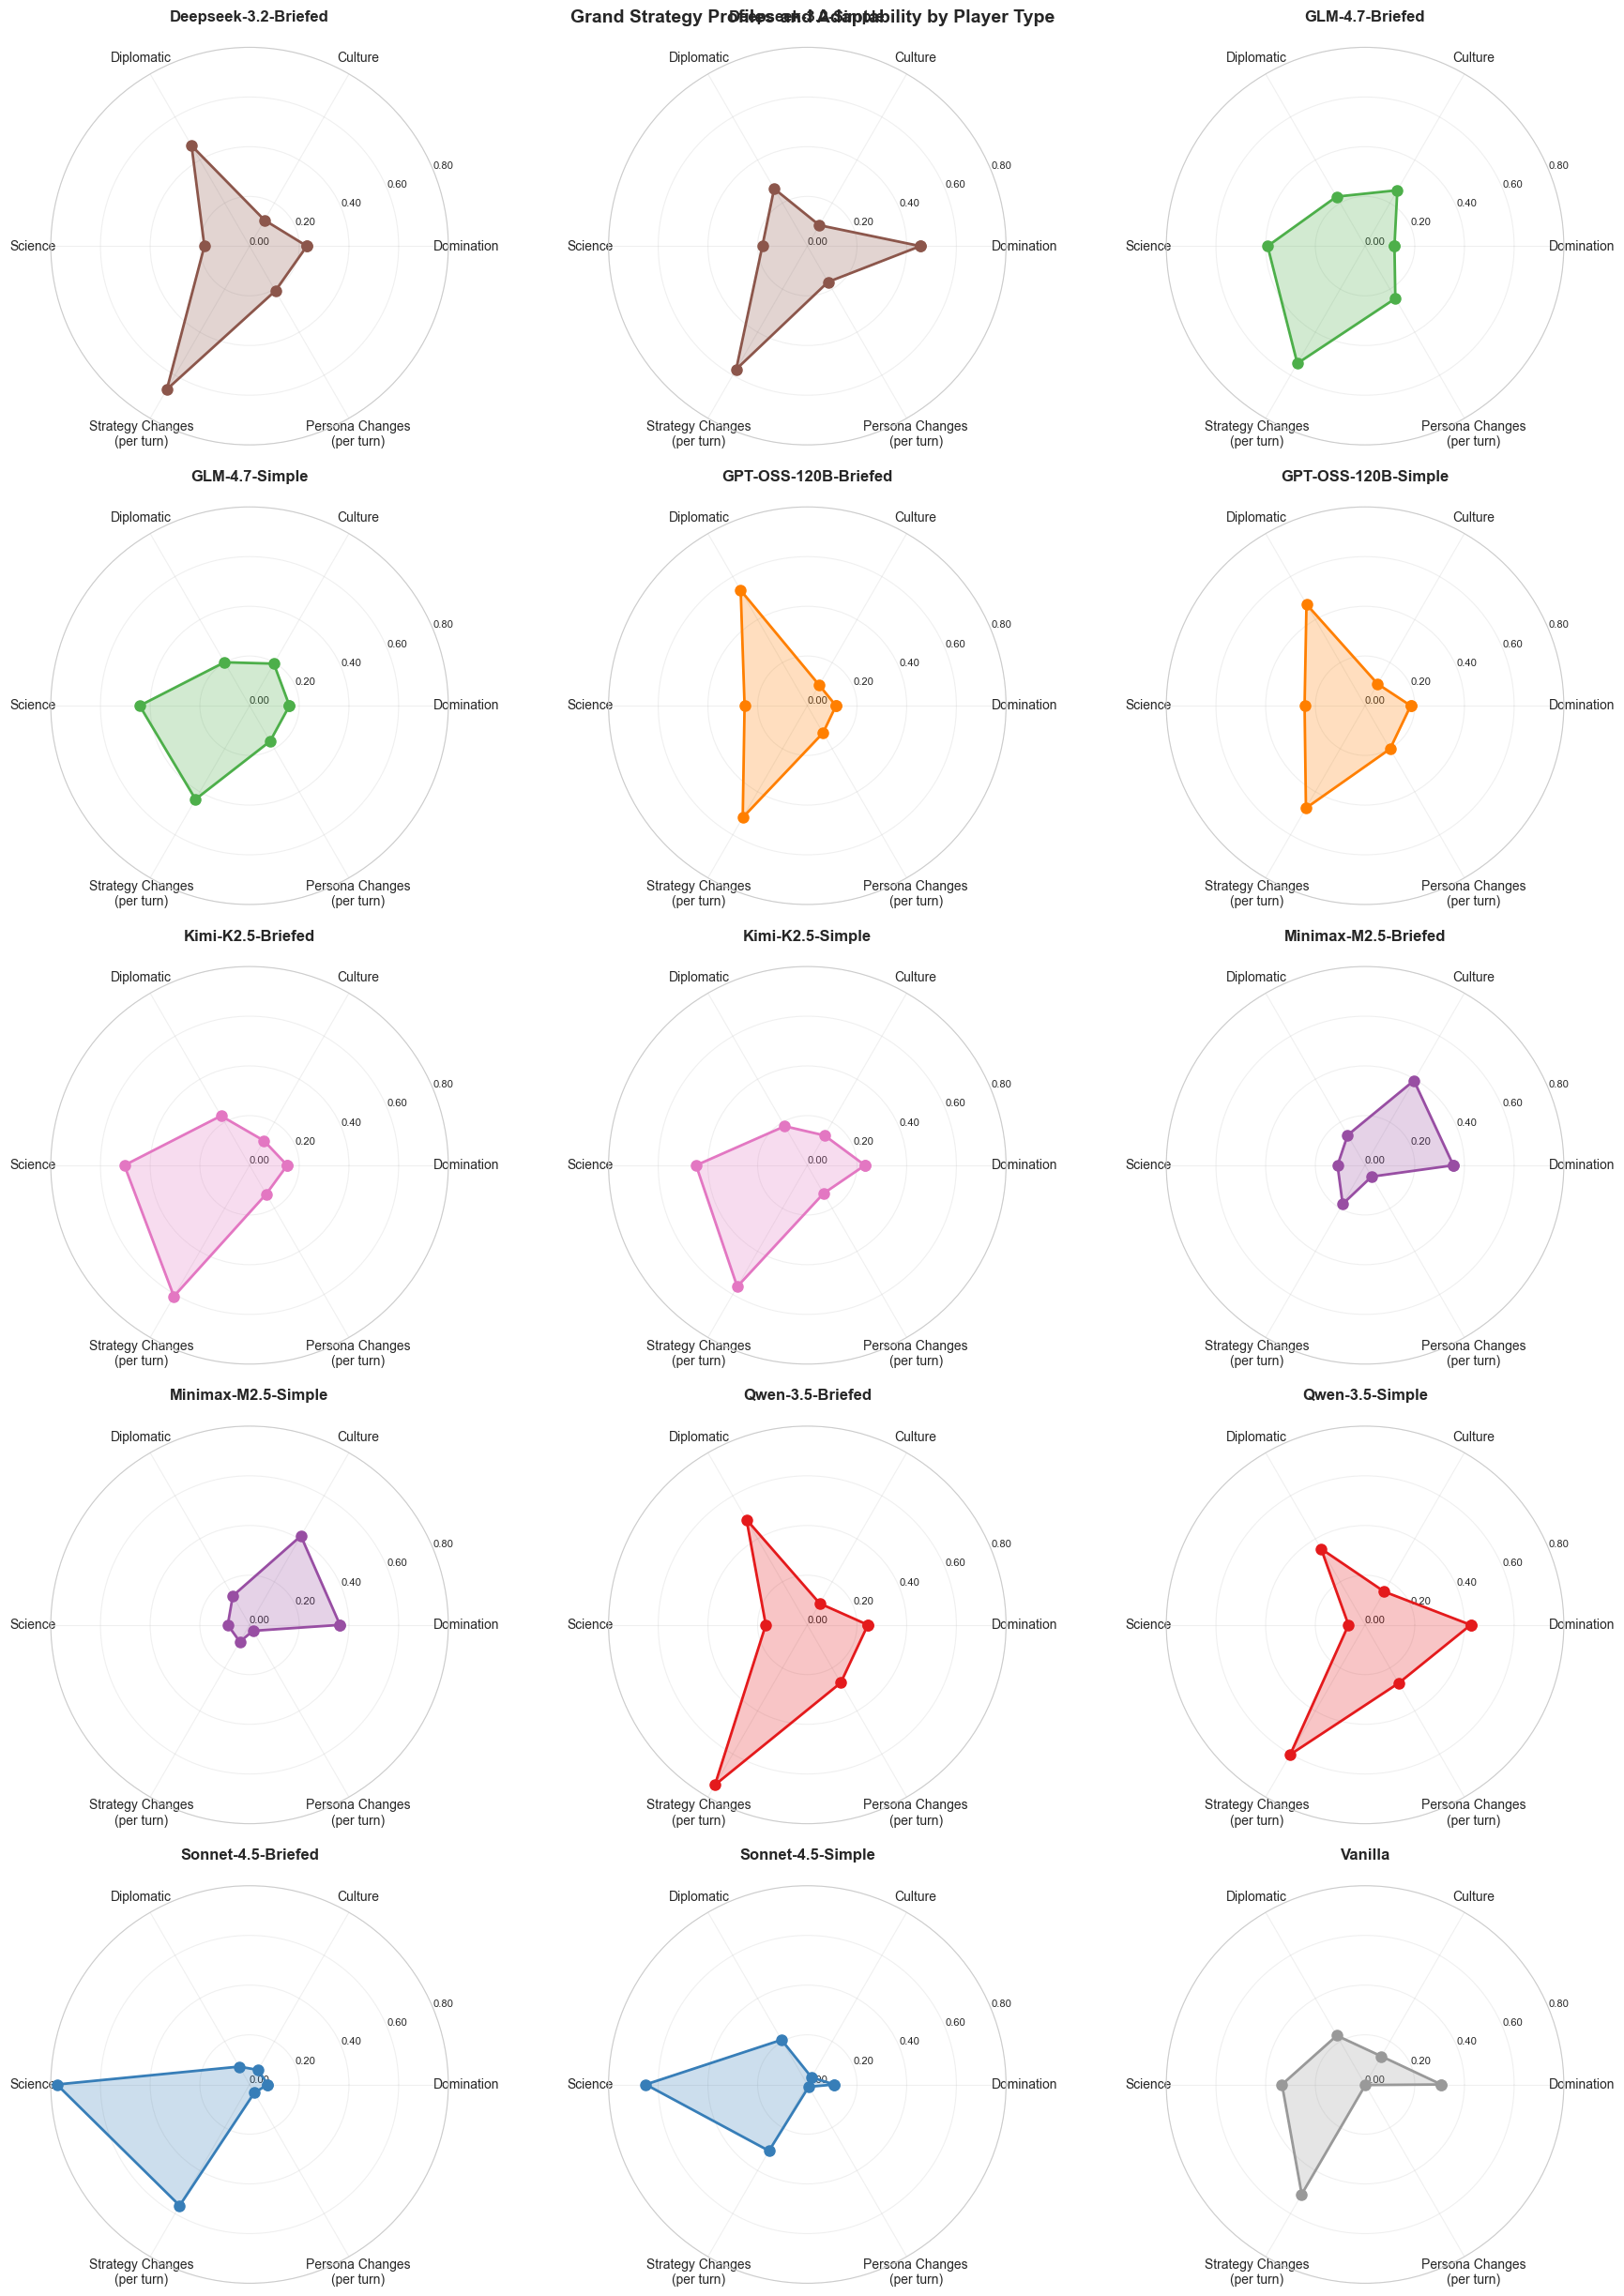


Grand Strategy Profiles and Adaptability by Player Type Summary:


,N,Domination,Culture,Diplomatic,Science,Strategy Changes (per turn),Persona Changes (per turn)
Deepseek-3.2-Briefed,116,"0.231 [0.173, 0.289]","0.121 [0.069, 0.173]","0.467 [0.407, 0.526]","0.182 [0.135, 0.229]","0.666 [0.651, 0.680]","0.208 [0.192, 0.223]"
Deepseek-3.2-Simple,116,"0.455 [0.384, 0.526]","0.097 [0.053, 0.141]","0.267 [0.203, 0.331]","0.181 [0.137, 0.225]","0.572 [0.555, 0.590]","0.167 [0.156, 0.177]"
GLM-4.7-Briefed,180,"0.118 [0.083, 0.153]","0.260 [0.206, 0.313]","0.230 [0.178, 0.282]","0.392 [0.334, 0.451]","0.545 [0.535, 0.556]","0.244 [0.231, 0.256]"
GLM-4.7-Simple,180,"0.160 [0.119, 0.202]","0.195 [0.147, 0.243]","0.202 [0.152, 0.251]","0.442 [0.382, 0.503]","0.435 [0.425, 0.445]","0.165 [0.156, 0.174]"
GPT-OSS-120B-Briefed,125,"0.115 [0.087, 0.144]","0.096 [0.059, 0.132]","0.536 [0.487, 0.585]","0.253 [0.195, 0.310]","0.520 [0.505, 0.534]","0.127 [0.113, 0.140]"
GPT-OSS-120B-Simple,125,"0.184 [0.140, 0.227]","0.101 [0.060, 0.143]","0.472 [0.419, 0.524]","0.243 [0.180, 0.307]","0.476 [0.461, 0.491]","0.201 [0.185, 0.217]"
Kimi-K2.5-Briefed,127,"0.152 [0.111, 0.193]","0.115 [0.075, 0.154]","0.230 [0.178, 0.282]","0.504 [0.444, 0.563]","0.609 [0.588, 0.629]","0.134 [0.120, 0.148]"
Kimi-K2.5-Simple,127,"0.232 [0.178, 0.286]","0.139 [0.091, 0.187]","0.182 [0.133, 0.230]","0.448 [0.392, 0.503]","0.564 [0.542, 0.586]","0.131 [0.119, 0.143]"
Minimax-M2.5-Briefed,49,"0.355 [0.221, 0.489]","0.394 [0.259, 0.528]","0.140 [0.046, 0.235]","0.111 [0.023, 0.199]","0.180 [0.167, 0.194]","0.053 [0.047, 0.058]"
Minimax-M2.5-Simple,49,"0.364 [0.228, 0.500]","0.413 [0.274, 0.553]","0.135 [0.040, 0.229]","0.088 [0.009, 0.167]","0.078 [0.070, 0.087]","0.028 [0.023, 0.032]"


(<Figure size 1800x2500 with 15 Axes>,
 array([<PolarAxes: title={'center': 'Deepseek-3.2-Briefed'}>,
        <PolarAxes: title={'center': 'Deepseek-3.2-Simple'}>,
        <PolarAxes: title={'center': 'GLM-4.7-Briefed'}>,
        <PolarAxes: title={'center': 'GLM-4.7-Simple'}>,
        <PolarAxes: title={'center': 'GPT-OSS-120B-Briefed'}>,
        <PolarAxes: title={'center': 'GPT-OSS-120B-Simple'}>,
        <PolarAxes: title={'center': 'Kimi-K2.5-Briefed'}>,
        <PolarAxes: title={'center': 'Kimi-K2.5-Simple'}>,
        <PolarAxes: title={'center': 'Minimax-M2.5-Briefed'}>,
        <PolarAxes: title={'center': 'Minimax-M2.5-Simple'}>,
        <PolarAxes: title={'center': 'Qwen-3.5-Briefed'}>,
        <PolarAxes: title={'center': 'Qwen-3.5-Simple'}>,
        <PolarAxes: title={'center': 'Sonnet-4.5-Briefed'}>,
        <PolarAxes: title={'center': 'Sonnet-4.5-Simple'}>,
        <PolarAxes: title={'center': 'Vanilla'}>], dtype=object))

In [8]:
# Calculate strategy and persona change rates (changes per turn of survival, not *100)
# Players can't change strategy after they're eliminated!
panel_df['strategy_change_rate'] = panel_df['strategy_changes'] / panel_df['survival_turn']
panel_df['persona_change_rate'] = panel_df['persona_changes'] / panel_df['survival_turn']

# Grand Strategy Choice Profiles - Radar Charts
# Shows the mean proportion of time each player type spent on each dimension
plot_strategy_radar_charts(
    panel_df,
    columns=['domination_ratio', 'culture_ratio', 'diplomatic_ratio', 
             'science_ratio', 'strategy_change_rate', 'persona_change_rate'],
    labels=['Domination', 'Culture', 'Diplomatic', 'Science',
            'Strategy Changes\n(per turn)', 'Persona Changes\n(per turn)'],
    title='Grand Strategy Profiles and Adaptability by Player Type',
    print_summary=True,
    ylim=(0, 0.8)
)

## 8. Nuke Behavior: Use-Nuke and Nuke Inclination

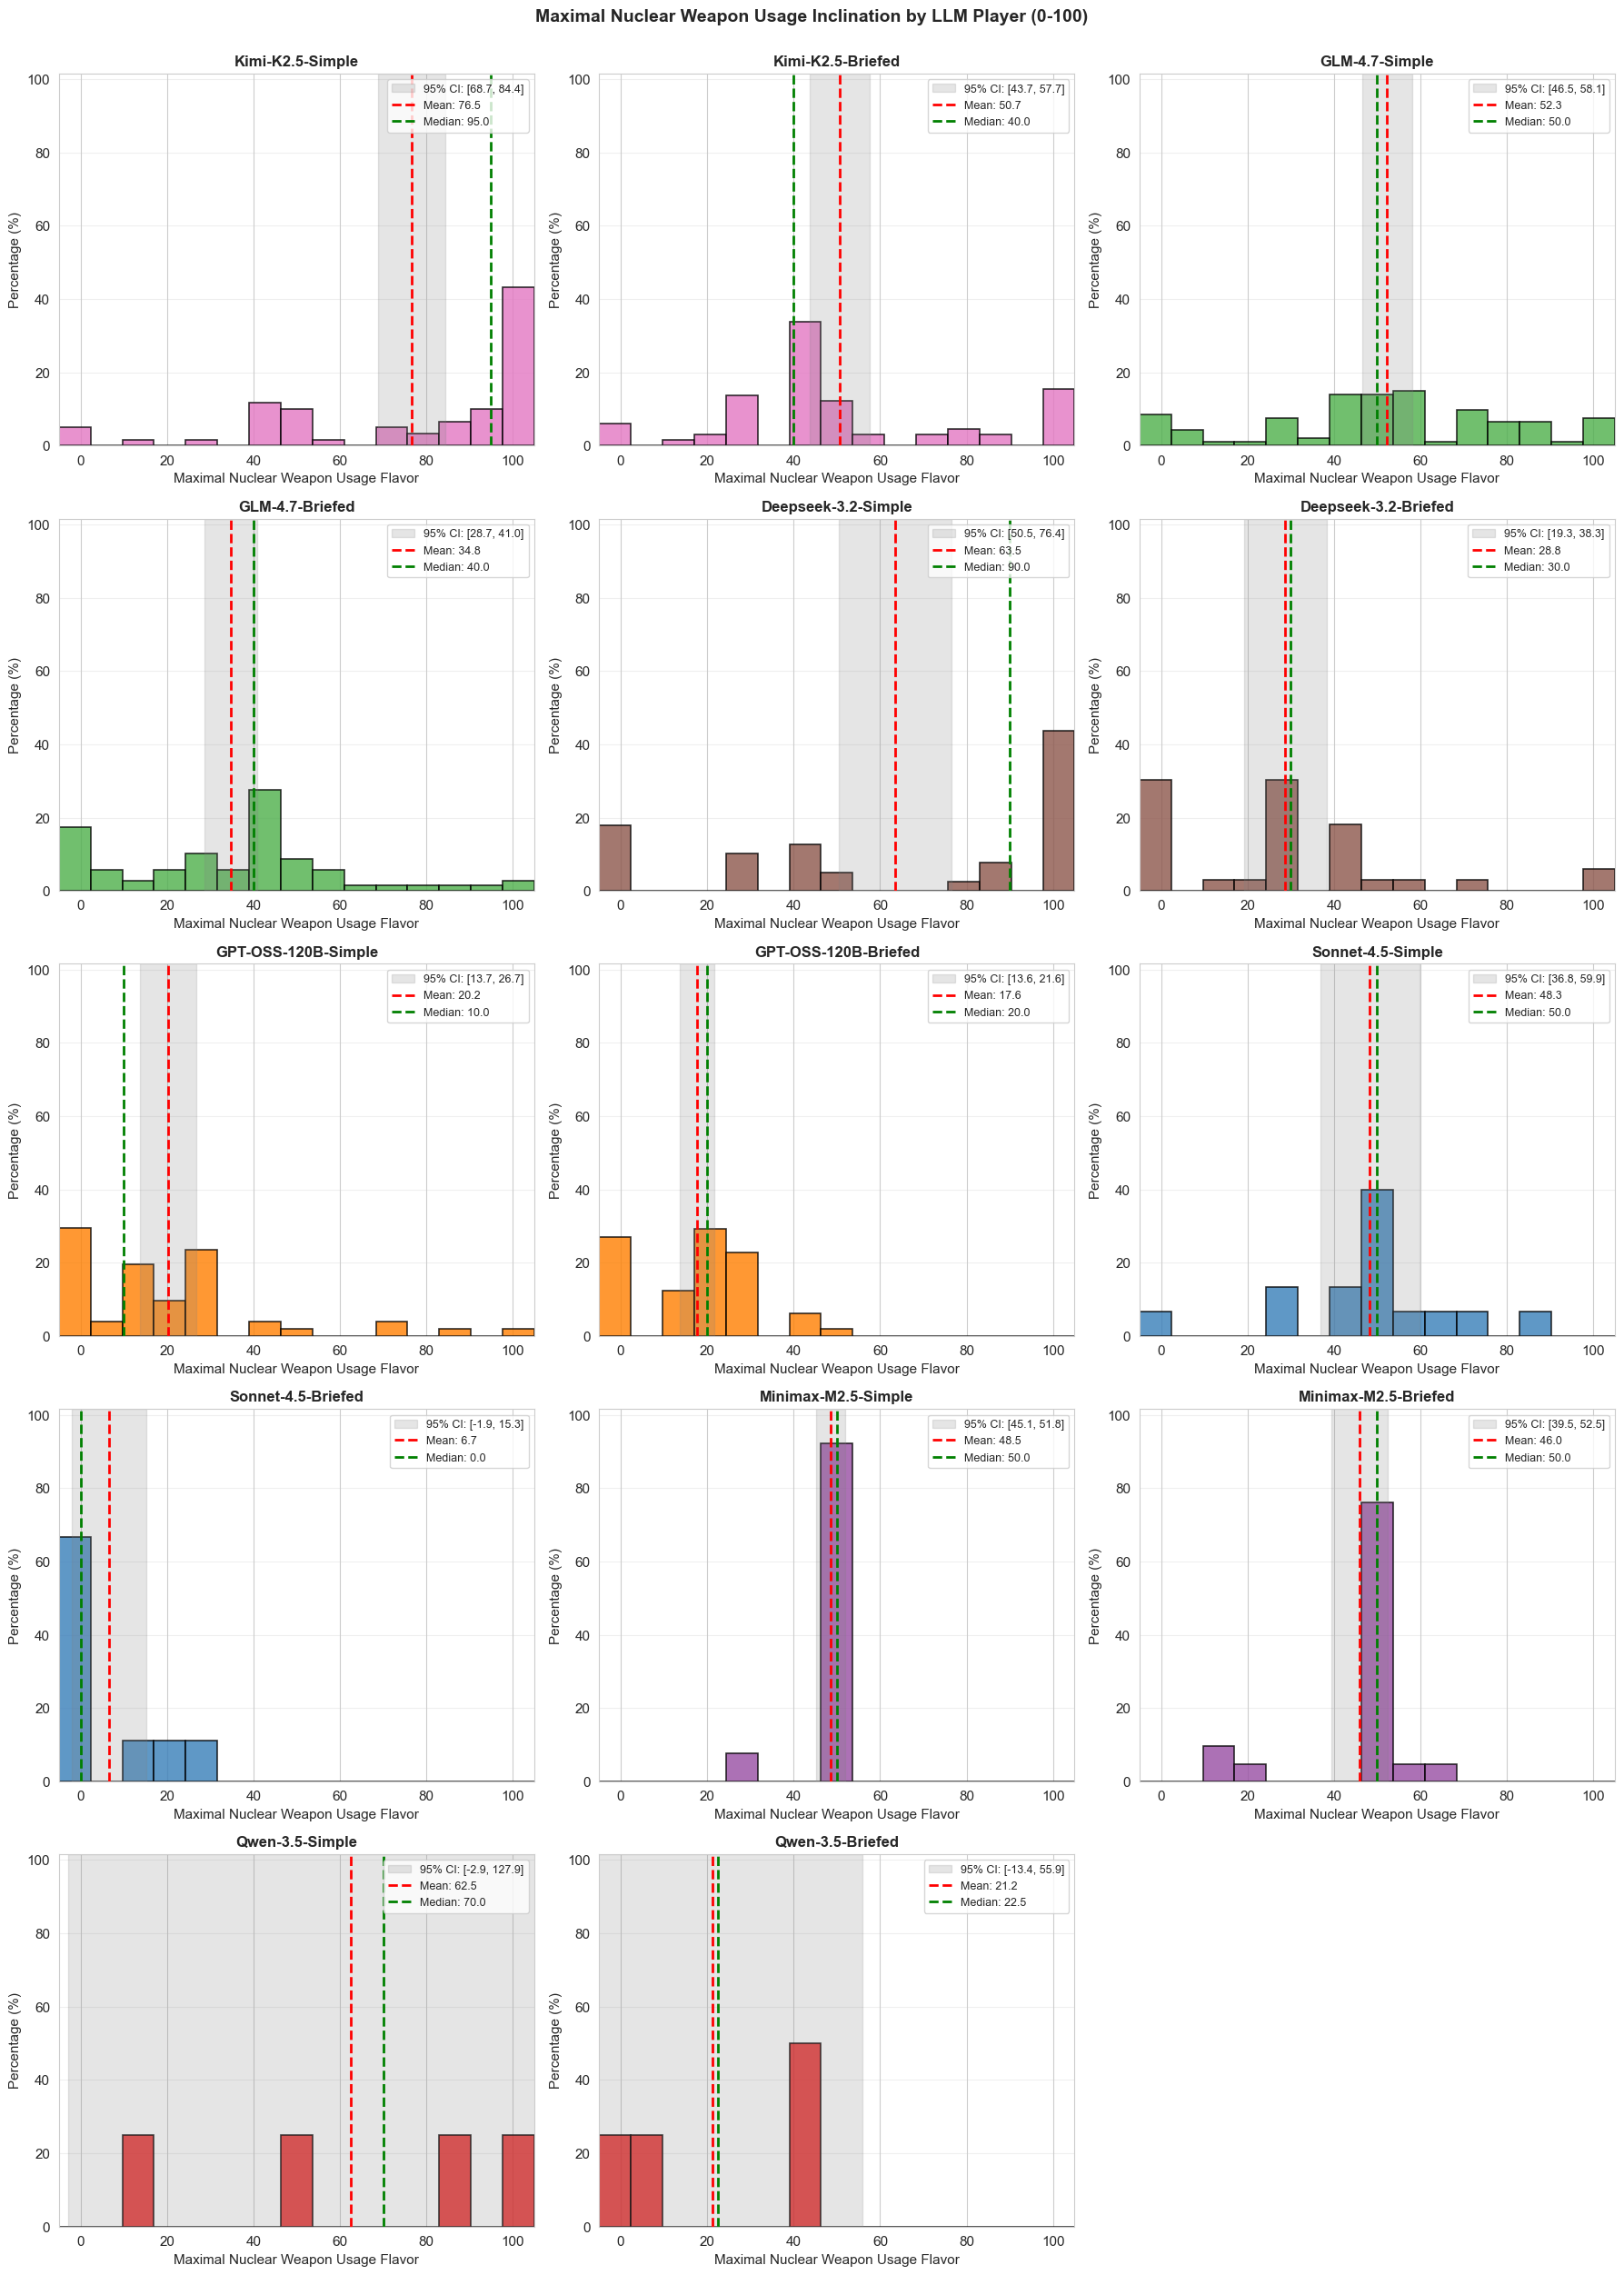


Maximal Nuclear Weapon Usage Inclination by LLM Player (0-100) Statistics:


,N,Mean,Median,Std,Min,Max,95% CI
Kimi-K2.5-Simple,60,76.55,95.0,30.21,0.0,100.0,"[68.75, 84.35]"
Kimi-K2.5-Briefed,65,50.69,40.0,28.10,0.0,100.0,"[43.73, 57.66]"
GLM-4.7-Simple,93,52.33,50.0,28.15,0.0,100.0,"[46.54, 58.13]"
GLM-4.7-Briefed,69,34.83,40.0,25.57,0.0,100.0,"[28.68, 40.97]"
Deepseek-3.2-Simple,39,63.46,90.0,39.95,0.0,100.0,"[50.51, 76.41]"
Deepseek-3.2-Briefed,33,28.79,30.0,26.75,0.0,100.0,"[19.30, 38.27]"
GPT-OSS-120B-Simple,51,20.20,10.0,23.09,0.0,100.0,"[13.70, 26.69]"
GPT-OSS-120B-Briefed,48,17.60,20.0,13.80,0.0,50.0,"[13.60, 21.61]"
Sonnet-4.5-Simple,15,48.33,50.0,20.85,0.0,90.0,"[36.79, 59.88]"
Sonnet-4.5-Briefed,9,6.67,0.0,11.18,0.0,30.0,"[-1.93, 15.26]"


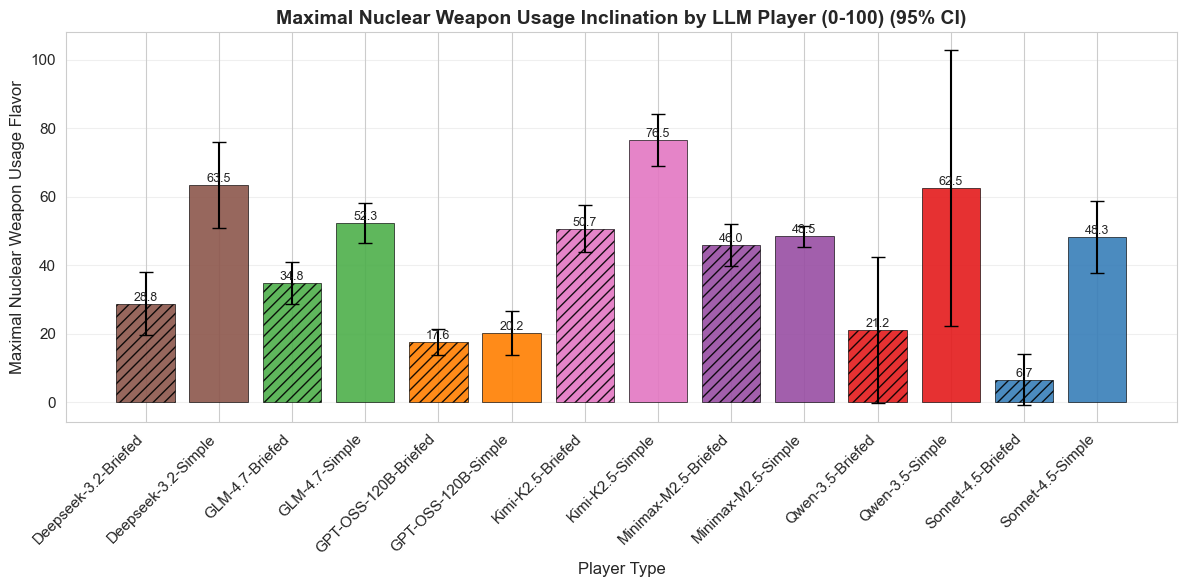

,Mean,Std,N
Deepseek-3.2-Briefed,28.787879,26.752053,33
Deepseek-3.2-Simple,63.461538,39.953161,39
GLM-4.7-Briefed,34.826087,25.567648,69
GLM-4.7-Simple,52.333333,28.147258,93
GPT-OSS-120B-Briefed,17.604167,13.799074,48
GPT-OSS-120B-Simple,20.196078,23.085943,51
Kimi-K2.5-Briefed,50.692308,28.102448,65
Kimi-K2.5-Simple,76.550000,30.206871,60
Minimax-M2.5-Briefed,45.952381,14.284524,21
Minimax-M2.5-Simple,48.461538,5.547002,13


In [9]:
# Filter to LLM players only (exclude Vanilla)
llm_players = [pt for pt in panel_df['player_type'].unique() if pt != 'Vanilla']

plot_distribution_histograms(
    panel_df,
    'use_nuke',
    'Maximal Nuclear Weapon Usage Flavor',
    'Maximal Nuclear Weapon Usage Inclination by LLM Player (0-100)',
    player_type_filter=llm_players
)

# Bar chart version with model-based colors
plot_bar_chart(
    panel_df[panel_df['player_type'].isin(llm_players)],
    value_col='use_nuke',
    category_col='player_type',
    xlabel='Player Type',
    ylabel='Maximal Nuclear Weapon Usage Flavor',
    title='Maximal Nuclear Weapon Usage Inclination by LLM Player (0-100)',
    figsize=(12,6),
    use_percentage=False,
    show_error_bars=True,
    color_by_category=True
)

c:\Users\John Chen\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\John Chen\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


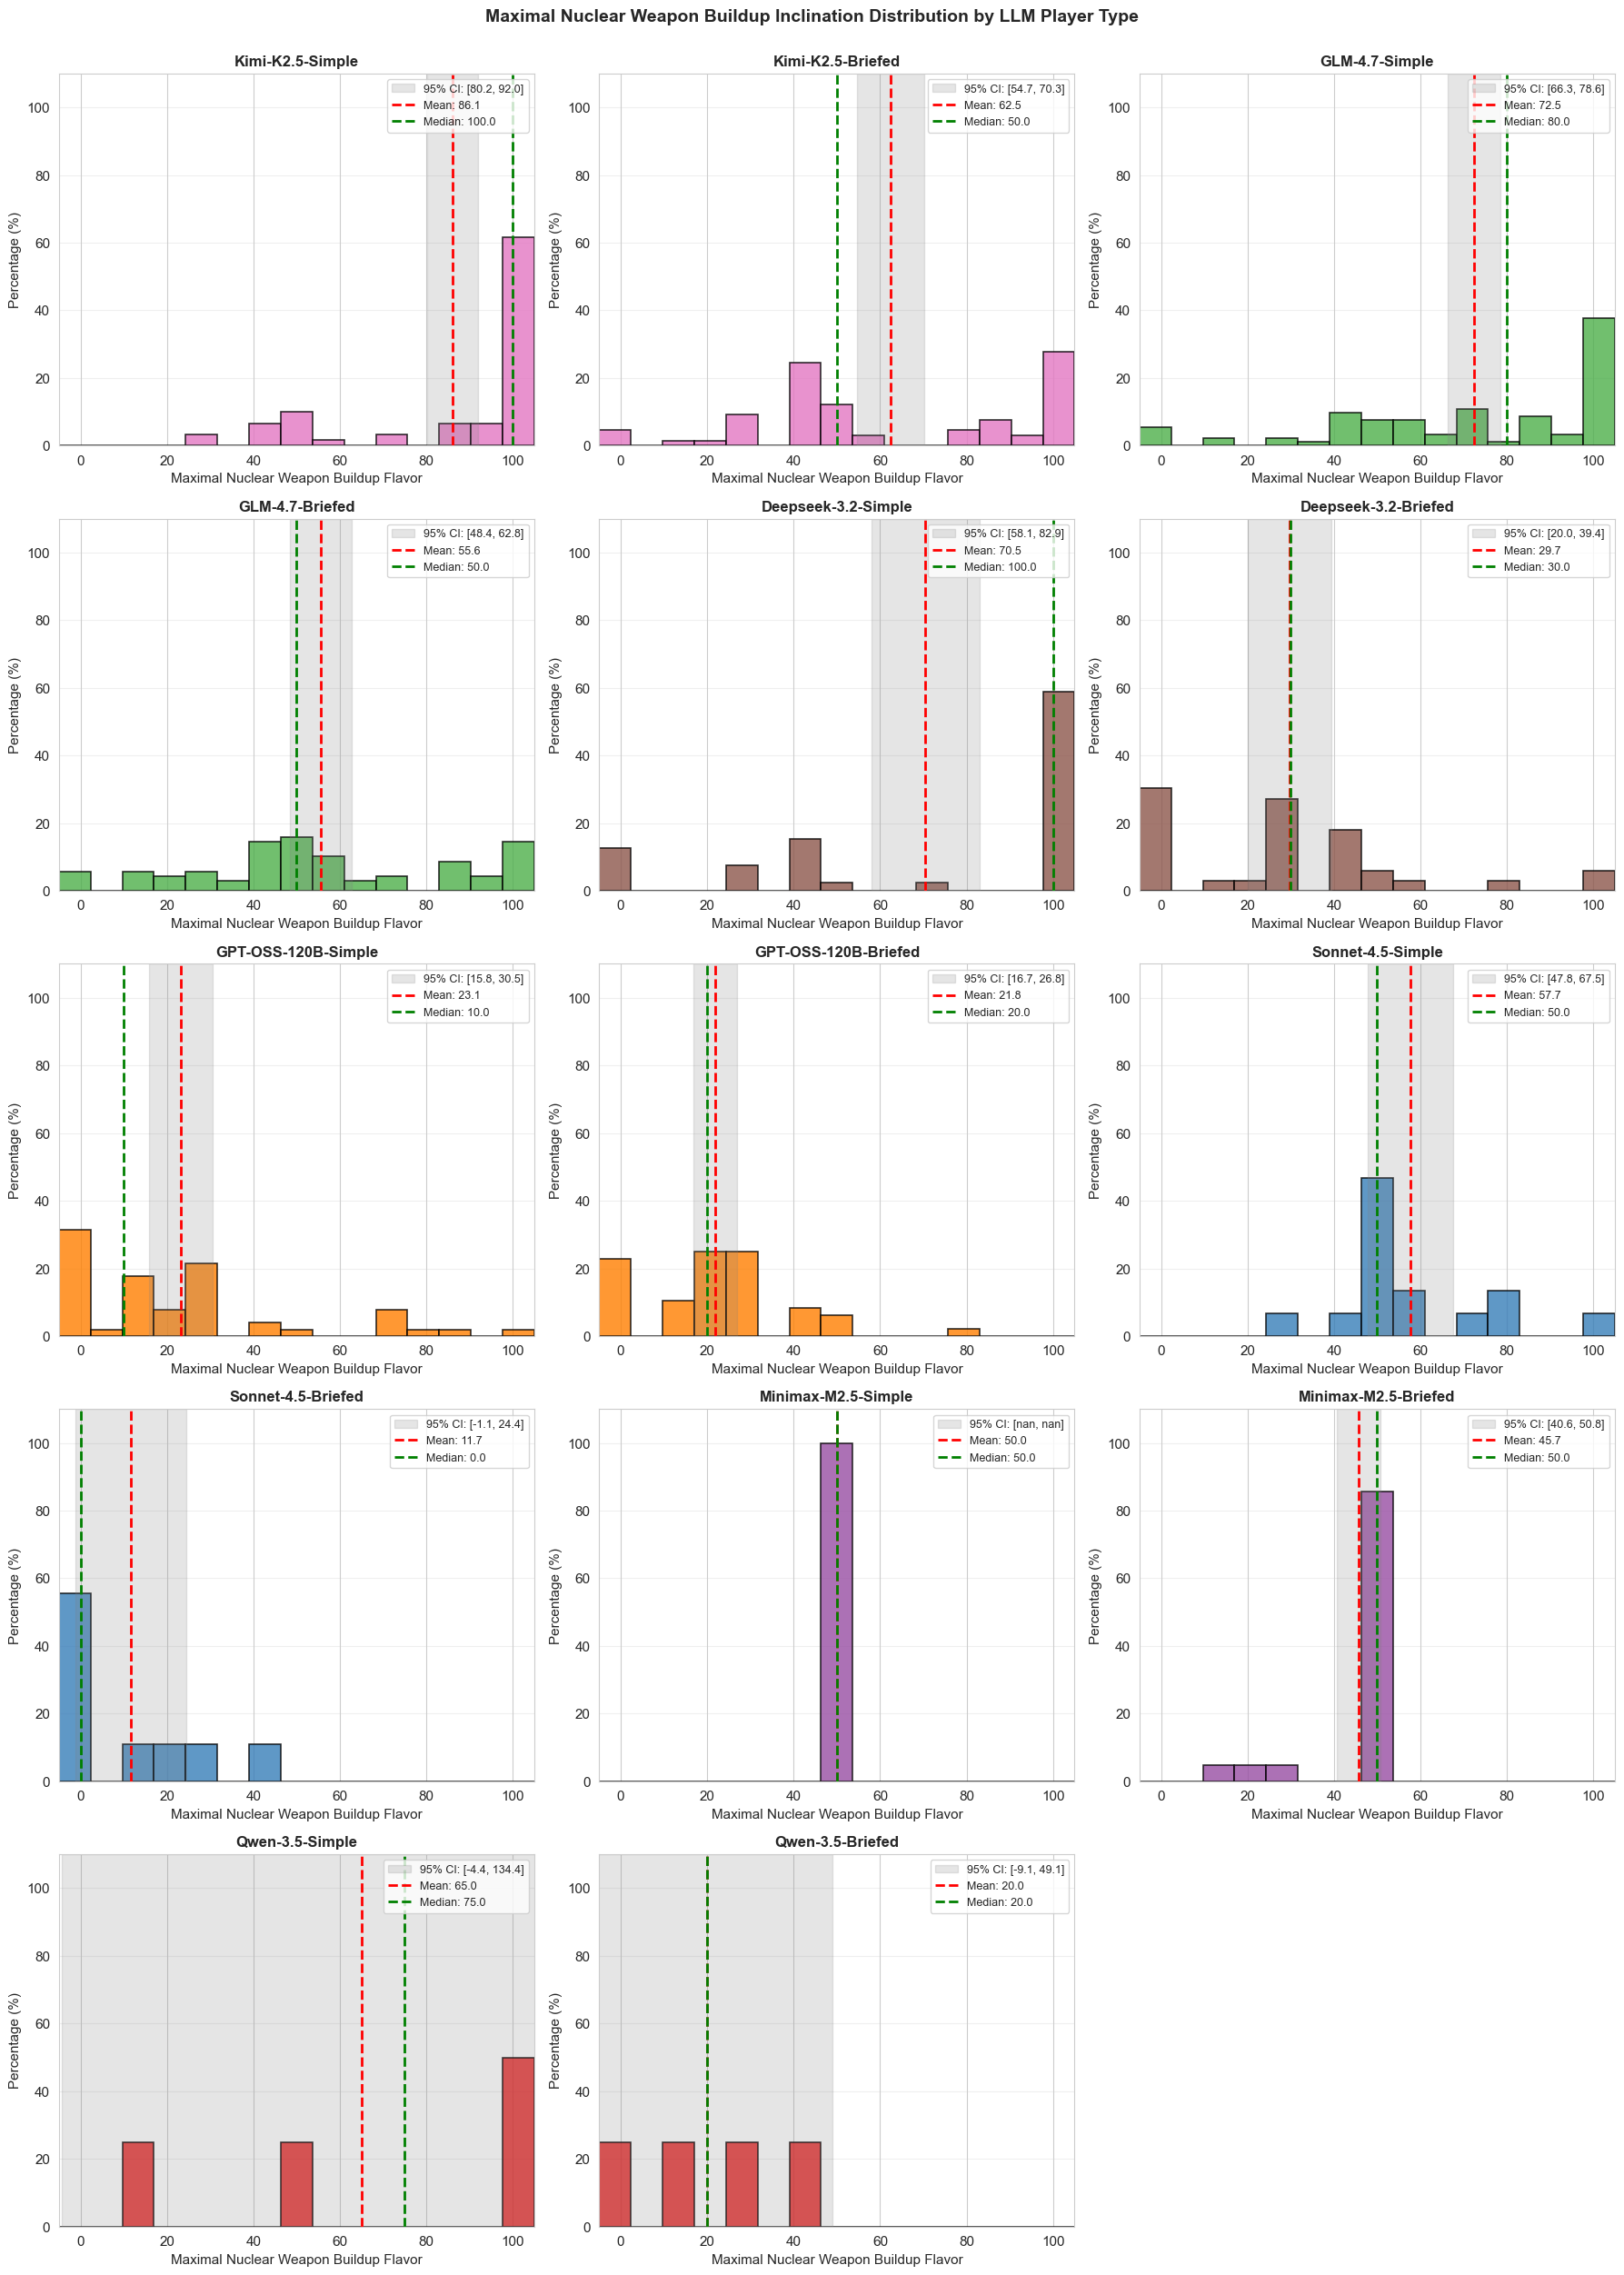


Maximal Nuclear Weapon Buildup Inclination Distribution by LLM Player Type Statistics:


c:\Users\John Chen\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\John Chen\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


,N,Mean,Median,Std,Min,Max,95% CI
Kimi-K2.5-Simple,60,86.08,100.0,22.72,30.0,100.0,"[80.21, 91.95]"
Kimi-K2.5-Briefed,65,62.46,50.0,31.44,0.0,100.0,"[54.67, 70.25]"
GLM-4.7-Simple,93,72.47,80.0,29.78,0.0,100.0,"[66.34, 78.61]"
GLM-4.7-Briefed,69,55.61,50.0,30.04,0.0,100.0,"[48.39, 62.82]"
Deepseek-3.2-Simple,39,70.51,100.0,38.32,0.0,100.0,"[58.09, 82.93]"
Deepseek-3.2-Briefed,33,29.70,30.0,27.36,0.0,100.0,"[20.00, 39.40]"
GPT-OSS-120B-Simple,51,23.14,10.0,26.10,0.0,100.0,"[15.80, 30.48]"
GPT-OSS-120B-Briefed,48,21.77,20.0,17.30,0.0,80.0,"[16.75, 26.80]"
Sonnet-4.5-Simple,15,57.67,50.0,17.82,30.0,100.0,"[47.80, 67.53]"
Sonnet-4.5-Briefed,9,11.67,0.0,16.58,0.0,45.0,"[-1.08, 24.41]"


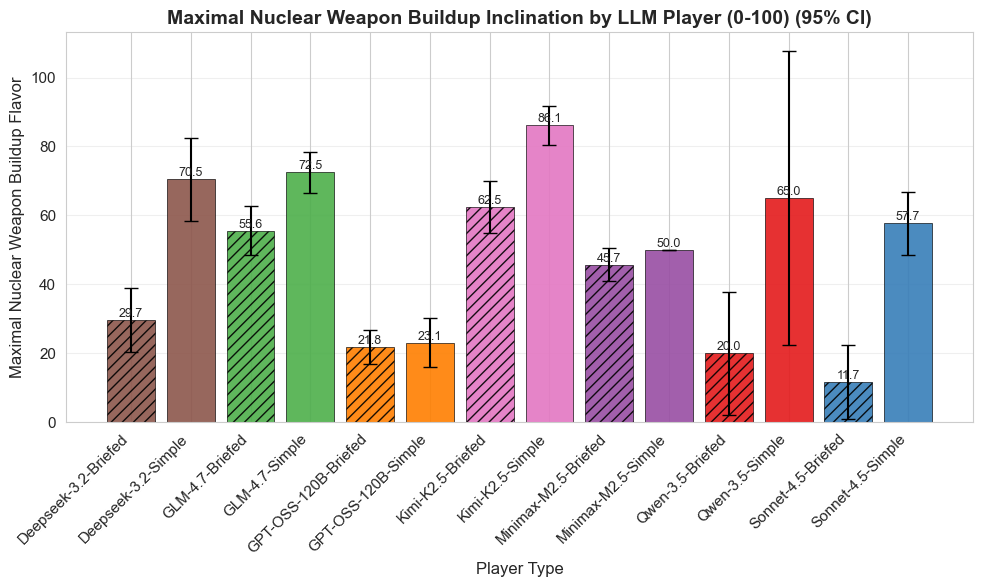

,Mean,Std,N
Deepseek-3.2-Briefed,29.696970,27.355855,33
Deepseek-3.2-Simple,70.512821,38.316461,39
GLM-4.7-Briefed,55.608696,30.036359,69
GLM-4.7-Simple,72.473118,29.778381,93
GPT-OSS-120B-Briefed,21.770833,17.304826,48
GPT-OSS-120B-Simple,23.137255,26.095225,51
Kimi-K2.5-Briefed,62.461538,31.438470,65
Kimi-K2.5-Simple,86.083333,22.719581,60
Minimax-M2.5-Briefed,45.714286,11.212238,21
Minimax-M2.5-Simple,50.000000,0.000000,13


In [10]:
plot_distribution_histograms(
    panel_df,
    'nuke',
    'Maximal Nuclear Weapon Buildup Flavor',
    'Maximal Nuclear Weapon Buildup Inclination Distribution by LLM Player Type',
    player_type_filter=llm_players
)

# Bar chart version with model-based colors
plot_bar_chart(
    panel_df[panel_df['player_type'].isin(llm_players)],
    value_col='nuke',
    category_col='player_type',
    xlabel='Player Type',
    ylabel='Maximal Nuclear Weapon Buildup Flavor',
    title='Maximal Nuclear Weapon Buildup Inclination by LLM Player (0-100)',
    use_percentage=False,
    show_error_bars=True,
    color_by_category=True
)